# 09 — Physical-unit evaluation and exports

## Purpose

This notebook evaluates the final **T3-Climate ConvLSTM-SE U-Net** model (**M5**) in physical temperature units (**°C**) and prepares outputs suitable for manuscript reporting and repository verification.

The training notebooks operate on normalized LST values. This notebook applies the inverse z-score transformation using the fixed train-only parameters:

\[
LST_C = LST_{norm}\,\sigma_{\mathrm{train}} + \mu_{\mathrm{train}}
\]

## Scope

This notebook does **not** retrain, reselect, or tune models. It performs post-training evaluation and export only.

Main outputs:

- model-comparison tables converted from normalized scale to °C;
- TEST ranking in °C;
- manuscript-ready summary plots;
- optional full-domain LST maps in °C if prediction rasters are available;
- optional triptych figures: observed LST, predicted LST, and pixel-wise agreement;
- metadata JSON documenting the conversion and evaluation protocol.

## Important methodological note

RMSE, MAE and bias in normalized scale are not temperature errors in °C. Because inverse z-score is linear, these metrics can be converted as:

\[
RMSE_C = RMSE_{norm}\,\sigma_{\mathrm{train}}
\]

\[
MAE_C = MAE_{norm}\,\sigma_{\mathrm{train}}
\]

\[
Bias_C = Bias_{norm}\,\sigma_{\mathrm{train}}
\]

\(R^2\) is unchanged by applying the same linear transformation to observed and predicted values.

In [ ]:
# ============================================================
# 09 — Imports and optional Google Drive mount
# ============================================================

from pathlib import Path
import os
import json
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import rasterio
    from rasterio.errors import NotGeoreferencedWarning
    warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)
    RASTERIO_AVAILABLE = True
except Exception as e:
    RASTERIO_AVAILABLE = False
    print("rasterio is not available. Raster export sections will be skipped.")
    print("Error:", repr(e))

try:
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print("scikit-learn is not available. Metric functions will use NumPy fallback.")
    print("Error:", repr(e))

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

# Optional Colab Drive mount
if Path("/content").exists() and not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Google Drive mount was not performed:", repr(e))

Mounted at /content/drive


In [ ]:
# ============================================================
# 09 — User configuration
# ============================================================

# Main project root. If needed, set this manually before running:
# os.environ["PROJECT_ROOT"] = "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling"
PROJECT_ROOT_OVERRIDE = os.environ.get("PROJECT_ROOT", "")

# Module 08 output folder. If auto-discovery fails, set manually:
# os.environ["MODULE08_OUT_DIR"] = "/content/drive/MyDrive/.../module08_independent_2016_2025"
MODULE08_OUT_DIR_OVERRIDE = os.environ.get("MODULE08_OUT_DIR", "")

# Optional existing full-domain export inventory from module 41B or similar.
# If empty, the notebook will search for inventories with pred/target raster paths.
# os.environ["PREDICTION_INVENTORY_CSV"] = "/content/drive/MyDrive/.../inventory.csv"
PREDICTION_INVENTORY_CSV_OVERRIDE = os.environ.get("PREDICTION_INVENTORY_CSV", "")

# Train-only LST normalization parameters.
# These values must match the normalization parameters used by the training notebooks.
# Verified values from the current project state:
MU_TRAIN = float(os.environ.get("LST_MU_TRAIN", "38.48322677612305"))
SIGMA_TRAIN = float(os.environ.get("LST_SIGMA_TRAIN", "4.032179355621338"))

# Temporal protocol
TRAIN_YEARS = [2016, 2017, 2018, 2019]
VALIDATION_YEARS = [2020, 2021, 2022]
TEST_YEARS = [2023, 2024, 2025]
ALL_YEARS = TRAIN_YEARS + VALIDATION_YEARS + TEST_YEARS

SPLIT_MAP = {y: "train" for y in TRAIN_YEARS}
SPLIT_MAP.update({y: "validation" for y in VALIDATION_YEARS})
SPLIT_MAP.update({y: "test" for y in TEST_YEARS})

# Figure year for manuscript-style triptych, if rasters are available.
REPRESENTATIVE_TEST_YEAR = 2024

print("Configured train-only LST parameters:")
print("  MU_TRAIN    =", MU_TRAIN)
print("  SIGMA_TRAIN =", SIGMA_TRAIN)

assert np.isfinite(MU_TRAIN), "MU_TRAIN is not finite."
assert np.isfinite(SIGMA_TRAIN) and SIGMA_TRAIN > 0, "SIGMA_TRAIN must be positive and finite."

Configured train-only LST parameters:
  MU_TRAIN    = 38.48322677612305
  SIGMA_TRAIN = 4.032179355621338


In [ ]:
# ============================================================
# 09 — Path discovery utilities
# ============================================================

def _clean_path_09(value):
    """Normalize an optional user path."""
    if value is None:
        return None
    value = str(value).strip()
    if not value:
        return None
    return Path(value).expanduser()


def _iter_search_roots_09():
    """
    Return existing roots in a controlled order.

    The search is deliberately restricted to the usual Colab/Drive
    locations and the current working directory.
    """
    roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/Shareddrives"),
        Path("/content/drive"),
        Path.cwd(),
    ]

    unique_roots = []
    seen = set()

    for root in roots:
        try:
            resolved = str(root.resolve())
        except Exception:
            resolved = str(root)

        if root.exists() and resolved not in seen:
            unique_roots.append(root)
            seen.add(resolved)

    return unique_roots


def find_project_root():
    """Resolve the project root without assuming a single folder name."""
    override = _clean_path_09(PROJECT_ROOT_OVERRIDE)

    if override is not None:
        if override.exists():
            return override
        raise FileNotFoundError(
            "PROJECT_ROOT override does not exist:\n"
            f"  {override}\n\n"
            "Correct the path in the user-configuration cell before continuing."
        )

    direct_candidates = [
        Path("/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling"),
        Path("/content/drive/MyDrive/Barranquilla"),
    ]

    for candidate in direct_candidates:
        if candidate.exists():
            return candidate

    # Infer the project root from the definitive Module 08 comparison files.
    signature_names = [
        "08F_eval_by_year_M1_M5.csv",
        "08F_eval_by_split_M1_M5.csv",
    ]

    for root in _iter_search_roots_09():
        for signature in signature_names:
            try:
                matches = list(root.rglob(signature))
            except (PermissionError, OSError):
                matches = []

            for match in matches:
                # Expected structure:
                # BASE_OUT/comparison_M1_M5/tables/<signature.csv>
                if (
                    match.parent.name == "tables"
                    and match.parent.parent.name == "comparison_M1_M5"
                ):
                    base_out = match.parent.parent.parent
                    return base_out.parent

    return Path.cwd()


def _is_valid_module08_base_09(path: Path):
    """
    Validate a candidate Module 08 base folder by its products rather
    than exclusively by its directory name.
    """
    if not path.exists() or not path.is_dir():
        return False

    expected_year = (
        path / "comparison_M1_M5" / "tables" / "08F_eval_by_year_M1_M5.csv"
    )
    expected_split = (
        path / "comparison_M1_M5" / "tables" / "08F_eval_by_split_M1_M5.csv"
    )

    return expected_year.exists() or expected_split.exists()


def find_module08_out(project_root: Path):
    """
    Resolve the Module 08 output folder robustly.

    Priority:
    1. Explicit MODULE08_OUT_DIR override.
    2. Standard directory names.
    3. Discovery from definitive comparison CSV files.
    4. Discovery from the legacy folder name.

    The function returns the folder that directly contains
    `comparison_M1_M5`.
    """
    override = _clean_path_09(MODULE08_OUT_DIR_OVERRIDE)

    if override is not None:
        if _is_valid_module08_base_09(override):
            return override

        # Permit a user to point directly to comparison_M1_M5.
        if (
            override.exists()
            and override.is_dir()
            and override.name == "comparison_M1_M5"
            and (override / "tables").exists()
        ):
            return override.parent

        raise FileNotFoundError(
            "MODULE08_OUT_DIR exists but does not contain the expected "
            "Module 08 comparison products:\n"
            f"  {override}\n\n"
            "The selected folder must directly contain:\n"
            "  comparison_M1_M5/tables/08F_eval_by_year_M1_M5.csv\n"
            "or\n"
            "  comparison_M1_M5/tables/08F_eval_by_split_M1_M5.csv"
        )

    direct_candidates = [
        project_root / "module08_independent_2016_2025",
        project_root / "08_model_outputs" / "module08_independent_2016_2025",
        project_root / "outputs" / "module08_independent_2016_2025",
        project_root / "08_model_outputs",
        project_root / "outputs",
        project_root,
    ]

    for candidate in direct_candidates:
        if _is_valid_module08_base_09(candidate):
            return candidate

    signature_names = [
        "08F_eval_by_year_M1_M5.csv",
        "08F_eval_by_split_M1_M5.csv",
    ]

    search_roots = []
    if project_root.exists():
        search_roots.append(project_root)

    for root in _iter_search_roots_09():
        if root not in search_roots:
            search_roots.append(root)

    discovered = []

    for root in search_roots:
        for signature in signature_names:
            try:
                matches = list(root.rglob(signature))
            except (PermissionError, OSError):
                matches = []

            for match in matches:
                if (
                    match.parent.name == "tables"
                    and match.parent.parent.name == "comparison_M1_M5"
                ):
                    candidate = match.parent.parent.parent
                    if _is_valid_module08_base_09(candidate):
                        discovered.append(candidate)

    # Remove duplicate paths while preserving order.
    unique_discovered = []
    seen = set()

    for candidate in discovered:
        try:
            key = str(candidate.resolve())
        except Exception:
            key = str(candidate)

        if key not in seen:
            unique_discovered.append(candidate)
            seen.add(key)

    if len(unique_discovered) == 1:
        return unique_discovered[0]

    if len(unique_discovered) > 1:
        candidates_text = "\n".join(
            f"  [{i}] {path}" for i, path in enumerate(unique_discovered, start=1)
        )
        raise RuntimeError(
            "More than one valid Module 08 output folder was found:\n"
            f"{candidates_text}\n\n"
            "Set MODULE08_OUT_DIR explicitly in the user-configuration cell "
            "to select the correct experiment."
        )

    # Legacy fallback: folder-name discovery.
    legacy_matches = []

    for root in search_roots:
        try:
            for path in root.rglob("module08_independent_2016_2025"):
                if path.is_dir():
                    legacy_matches.append(path)
        except (PermissionError, OSError):
            continue

    valid_legacy = [
        path for path in legacy_matches if _is_valid_module08_base_09(path)
    ]

    if len(valid_legacy) == 1:
        return valid_legacy[0]

    raise FileNotFoundError(
        "Module 08 outputs could not be located automatically.\n\n"
        "The notebook searched for the definitive files:\n"
        "  08F_eval_by_year_M1_M5.csv\n"
        "  08F_eval_by_split_M1_M5.csv\n\n"
        "Set the exact folder manually in the user-configuration cell, for example:\n"
        '  os.environ["MODULE08_OUT_DIR"] = '
        '"/content/drive/MyDrive/.../module08_independent_2016_2025"\n\n'
        "The selected folder must directly contain the subfolder "
        "`comparison_M1_M5`."
    )


PROJECT_ROOT = find_project_root()
BASE_OUT = find_module08_out(PROJECT_ROOT)

OUTPUT_DIR = BASE_OUT / "09_physical_unit_evaluation_and_exports"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
RASTER_DIR = OUTPUT_DIR / "rasters_celsius"
METADATA_DIR = OUTPUT_DIR / "metadata"

for directory in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, RASTER_DIR, METADATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BASE_OUT    :", BASE_OUT)
print("OUTPUT_DIR  :", OUTPUT_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling
BASE_OUT    : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025
OUTPUT_DIR  : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports


In [ ]:
# ============================================================
# 09 — Model specifications and helper functions
# ============================================================

MODEL_SPECS = [
    {
        "model": "M1_UNet",
        "model_label": "M1 — U-Net baseline",
        "aliases": ["M1_UNet", "M1", "unet_baseline"],
    },
    {
        "model": "M2_SE_UNet",
        "model_label": "M2 — SE U-Net",
        "aliases": ["M2_SE_UNet", "M2", "se_unet"],
    },
    {
        "model": "M3_ConvLSTM_UNet",
        "model_label": "M3 — ConvLSTM U-Net",
        "aliases": ["M3_ConvLSTM_UNet", "M3", "convlstm_unet"],
    },
    {
        "model": "M4_ConvLSTM_SE_UNet",
        "model_label": "M4 — ConvLSTM-SE U-Net",
        "aliases": ["M4_ConvLSTM_SE_UNet", "M4", "convlstm_se_unet"],
    },
    {
        "model": "M5_T3Climate_ConvLSTM_SE_UNet",
        "model_label": "M5 — T3-Climate ConvLSTM-SE U-Net",
        "aliases": ["M5_T3Climate_ConvLSTM_SE_UNet", "M5", "M5B", "t3_climate"],
    },
]

MODEL_LABEL_MAP = {m["model"]: m["model_label"] for m in MODEL_SPECS}

REQUIRED_SPLIT_COLS = ["model", "best_epoch", "split", "loss", "mae", "rmse", "bias", "r2", "n_valid_pixels"]
REQUIRED_YEAR_COLS = ["model", "split", "target_year", "loss", "mae", "rmse", "bias", "r2", "n_valid_pixels"]


def normalize_text(x):
    return str(x).lower().replace("-", "_").replace(" ", "_")


def ensure_cols(df, cols):
    return all(c in df.columns for c in cols)


def standardize_model_column(df, fallback_model):
    df = df.copy()
    if "model" not in df.columns:
        df["model"] = fallback_model
    df["model"] = df["model"].astype(str)
    for spec in MODEL_SPECS:
        aliases = {normalize_text(a) for a in spec["aliases"]}
        mask = df["model"].map(normalize_text).isin(aliases)
        df.loc[mask, "model"] = spec["model"]
    return df


def convert_metrics_to_celsius(df, level):
    """Convert RMSE, MAE and bias from normalized scale to °C."""
    df = df.copy()

    rename_map = {
        "loss": "loss_norm",
        "mae": "mae_norm",
        "rmse": "rmse_norm",
        "bias": "bias_norm",
    }
    for old, new in rename_map.items():
        if old in df.columns and new not in df.columns:
            df[new] = df[old]

    df["mae_c"] = df["mae_norm"] * SIGMA_TRAIN
    df["rmse_c"] = df["rmse_norm"] * SIGMA_TRAIN
    df["bias_c"] = df["bias_norm"] * SIGMA_TRAIN
    df["abs_bias_c"] = df["bias_c"].abs()
    df["r2"] = df["r2"].astype(float)

    df["lst_mu_train_c"] = MU_TRAIN
    df["lst_sigma_train_c"] = SIGMA_TRAIN
    df["metric_scale_note"] = (
        "RMSE, MAE and bias converted from normalized scale to °C using train-only sigma; "
        "R2 unchanged under linear inverse z-score."
    )
    df["aggregation_level"] = level

    if "model_label" not in df.columns:
        df["model_label"] = df["model"].map(MODEL_LABEL_MAP).fillna(df["model"])

    return df


def save_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def display_or_print(df, n=10):
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n).to_string())

In [ ]:
# ============================================================
# 09 — Load normalized comparison outputs from 08F
# ============================================================

COMPARE_OUT = BASE_OUT / "comparison_M1_M5"
COMPARE_TABLE_DIR = COMPARE_OUT / "tables"

split_csv = COMPARE_TABLE_DIR / "08F_eval_by_split_M1_M5.csv"
year_csv = COMPARE_TABLE_DIR / "08F_eval_by_year_M1_M5.csv"

def load_from_08f_tables():
    if not split_csv.exists() or not year_csv.exists():
        return None, None

    split_df = pd.read_csv(split_csv)
    year_df = pd.read_csv(year_csv)

    split_df = standardize_model_column(split_df, fallback_model="")
    year_df = standardize_model_column(year_df, fallback_model="")

    if not ensure_cols(split_df, REQUIRED_SPLIT_COLS):
        raise ValueError(f"Split table does not contain required columns: {split_csv}")
    if not ensure_cols(year_df, REQUIRED_YEAR_COLS):
        raise ValueError(f"Year table does not contain required columns: {year_csv}")

    return split_df, year_df


def find_model_dir(base_out, spec):
    aliases = [normalize_text(a) for a in spec["aliases"]]
    candidates = []
    for p in base_out.rglob("*"):
        if p.is_dir():
            name = normalize_text(p.name)
            if any(a in name for a in aliases):
                candidates.append(p)
    scored = []
    for p in candidates:
        score = 0
        if (p / "evaluation").exists():
            score += 10
        if list(p.rglob("*.csv")):
            score += 2
        scored.append((score, len(str(p)), p))
    if not scored:
        return None
    scored.sort(key=lambda x: (-x[0], x[1]))
    return scored[0][2]


def choose_eval_csv(model_dir, required_cols, kind):
    if model_dir is None:
        return None, None

    candidates = []
    for p in sorted(model_dir.rglob("*.csv")):
        name = normalize_text(p.name)
        if "eval" in name or "metric" in name:
            if kind == "split" and any(k in name for k in ["split", "by_split", "eval_by_split"]):
                candidates.append(p)
            elif kind == "year" and any(k in name for k in ["year", "target", "by_year", "eval_by_year"]):
                candidates.append(p)

    if not candidates:
        candidates = sorted(model_dir.rglob("*.csv"))

    for p in candidates:
        try:
            df = pd.read_csv(p)
        except Exception:
            continue
        if ensure_cols(df, required_cols):
            return p, df
    return None, None


def load_by_scanning_model_dirs():
    split_tables = []
    year_tables = []
    inventory = []

    for spec in MODEL_SPECS:
        model_dir = find_model_dir(BASE_OUT, spec)
        split_path, split_df = choose_eval_csv(model_dir, REQUIRED_SPLIT_COLS, "split")
        year_path, year_df = choose_eval_csv(model_dir, REQUIRED_YEAR_COLS, "year")

        inventory.append({
            "model": spec["model"],
            "model_label": spec["model_label"],
            "model_dir": str(model_dir) if model_dir else None,
            "split_csv": str(split_path) if split_path else None,
            "year_csv": str(year_path) if year_path else None,
            "split_valid": split_df is not None,
            "year_valid": year_df is not None,
        })

        if split_df is not None:
            split_df = standardize_model_column(split_df, spec["model"])
            split_tables.append(split_df[REQUIRED_SPLIT_COLS].copy())

        if year_df is not None:
            year_df = standardize_model_column(year_df, spec["model"])
            year_tables.append(year_df[REQUIRED_YEAR_COLS].copy())

    inv = pd.DataFrame(inventory)
    inv.to_csv(METADATA_DIR / "09_input_evaluation_file_inventory.csv", index=False)

    if len(split_tables) != len(MODEL_SPECS) or len(year_tables) != len(MODEL_SPECS):
        print("Could not find valid evaluation tables for all models.")
        display_or_print(inv, n=20)
        raise FileNotFoundError(
            "Run 08F first or set MODULE08_OUT_DIR to the correct module08 output folder."
        )

    return pd.concat(split_tables, ignore_index=True), pd.concat(year_tables, ignore_index=True)


split_norm, year_norm = load_from_08f_tables()
if split_norm is None:
    print("08F consolidated tables not found. Scanning model evaluation folders...")
    split_norm, year_norm = load_by_scanning_model_dirs()
else:
    print("Loaded normalized evaluation tables from 08F outputs:")
    print("  ", split_csv)
    print("  ", year_csv)

split_norm["model_label"] = split_norm["model"].map(MODEL_LABEL_MAP).fillna(split_norm["model"])
year_norm["model_label"] = year_norm["model"].map(MODEL_LABEL_MAP).fillna(year_norm["model"])

print("Normalized split-level table:")
display_or_print(split_norm, n=15)

print("Normalized year-level table:")
display_or_print(year_norm, n=15)

Loaded normalized evaluation tables from 08F outputs:
   /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/comparison_M1_M5/tables/08F_eval_by_split_M1_M5.csv
   /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/comparison_M1_M5/tables/08F_eval_by_year_M1_M5.csv
Normalized split-level table:


,model,best_epoch,split,loss,mae,rmse,bias,r2,n_valid_pixels,model_label
0,M1_UNet,8,train,0.143702,0.423533,0.546554,-0.158843,0.661395,12803928,M1 — U-Net baseline
1,M1_UNet,8,validation,0.124956,0.401673,0.504678,0.061212,0.730849,2551475,M1 — U-Net baseline
2,M1_UNet,8,test,0.185778,0.499629,0.620150,-0.176204,0.598296,2565780,M1 — U-Net baseline
3,M2_SE_UNet,16,train,0.144682,0.423012,0.549116,-0.171111,0.658212,12803928,M2 — SE U-Net
4,M2_SE_UNet,16,validation,0.125370,0.402082,0.505591,0.044226,0.729875,2551475,M2 — SE U-Net
5,M2_SE_UNet,16,test,0.191859,0.508549,0.630716,-0.191106,0.584490,2565780,M2 — SE U-Net
6,M3_ConvLSTM_UNet,20,train,0.128641,0.401525,0.514837,-0.065963,0.699554,12803928,M3 — ConvLSTM U-Net
7,M3_ConvLSTM_UNet,20,validation,0.135201,0.429970,0.523735,0.151828,0.710139,2551475,M3 — ConvLSTM U-Net
8,M3_ConvLSTM_UNet,20,test,0.174441,0.479279,0.599513,-0.077921,0.624586,2565780,M3 — ConvLSTM U-Net
9,M4_ConvLSTM_SE_UNet,1,train,0.163436,0.454905,0.584652,-0.165401,0.612544,12803928,M4 — ConvLSTM-SE U-Net


Normalized year-level table:


,model,split,target_year,loss,mae,rmse,bias,r2,n_valid_pixels,model_label
0,M1_UNet,train,2016,0.127290,0.397181,0.512462,-0.139854,0.633804,3208500,M1 — U-Net baseline
1,M1_UNet,train,2017,0.111373,0.368017,0.477598,0.008049,0.711579,3195756,M1 — U-Net baseline
2,M1_UNet,train,2018,0.153489,0.444032,0.565238,-0.196101,0.691640,3192906,M1 — U-Net baseline
3,M1_UNet,train,2019,0.182597,0.484817,0.620113,-0.307064,0.545767,3206766,M1 — U-Net baseline
4,M1_UNet,validation,2020,0.146972,0.437140,0.548518,-0.000797,0.658187,841746,M1 — U-Net baseline
5,M1_UNet,validation,2021,0.132434,0.413803,0.519469,0.010633,0.697521,854472,M1 — U-Net baseline
6,M1_UNet,validation,2022,0.095815,0.354646,0.440595,0.172773,0.765296,855257,M1 — U-Net baseline
7,M1_UNet,test,2023,0.286866,0.654477,0.776112,-0.623866,0.369157,855218,M1 — U-Net baseline
8,M1_UNet,test,2024,0.112944,0.371537,0.482359,-0.263029,0.663583,855263,M1 — U-Net baseline
9,M1_UNet,test,2025,0.157531,0.472882,0.564582,0.358237,0.597910,855299,M1 — U-Net baseline


In [ ]:
# ============================================================
# 09 — Convert normalized evaluation metrics to Celsius
# ============================================================

split_c = convert_metrics_to_celsius(split_norm, level="split")
year_c = convert_metrics_to_celsius(year_norm, level="year")

split_c_path = TABLE_DIR / "09_model_comparison_by_split_celsius.csv"
year_c_path = TABLE_DIR / "09_model_comparison_by_year_celsius.csv"

split_c.to_csv(split_c_path, index=False, encoding="utf-8-sig")
year_c.to_csv(year_c_path, index=False, encoding="utf-8-sig")

test_rank_c = (
    split_c.loc[split_c["split"].astype(str).str.lower() == "test"]
    .copy()
    .sort_values(["rmse_c", "mae_c", "abs_bias_c"], ascending=[True, True, True])
    .reset_index(drop=True)
)
test_rank_c.insert(0, "test_rank_rmse_c", np.arange(1, len(test_rank_c) + 1))

test_rank_path = TABLE_DIR / "09_test_ranking_celsius.csv"
test_rank_c.to_csv(test_rank_path, index=False, encoding="utf-8-sig")

key_rows = []
def get_test_row(model_key):
    sub = test_rank_c[test_rank_c["model"] == model_key]
    return sub.iloc[0] if len(sub) else None

for a, b, label in [
    ("M3_ConvLSTM_UNet", "M1_UNet", "M3 vs M1: explicit temporal memory vs baseline"),
    ("M4_ConvLSTM_SE_UNet", "M3_ConvLSTM_UNet", "M4 vs M3: SE within ConvLSTM architecture"),
    ("M5_T3Climate_ConvLSTM_SE_UNet", "M4_ConvLSTM_SE_UNet", "M5 vs M4: climate-radiative augmentation"),
    ("M5_T3Climate_ConvLSTM_SE_UNet", "M1_UNet", "M5 vs M1: final model vs baseline"),
]:
    ra = get_test_row(a)
    rb = get_test_row(b)
    if ra is not None and rb is not None:
        key_rows.append({
            "comparison": label,
            "model_a": a,
            "model_b": b,
            "delta_rmse_c_a_minus_b": float(ra["rmse_c"] - rb["rmse_c"]),
            "delta_mae_c_a_minus_b": float(ra["mae_c"] - rb["mae_c"]),
            "delta_bias_c_a_minus_b": float(ra["bias_c"] - rb["bias_c"]),
            "delta_r2_a_minus_b": float(ra["r2"] - rb["r2"]),
            "relative_rmse_change_percent": float((ra["rmse_c"] - rb["rmse_c"]) / rb["rmse_c"] * 100.0),
        })

key_comp_c = pd.DataFrame(key_rows)
key_comp_path = TABLE_DIR / "09_key_model_comparisons_celsius.csv"
key_comp_c.to_csv(key_comp_path, index=False, encoding="utf-8-sig")

print("Exported Celsius evaluation tables:")
print(" ", split_c_path)
print(" ", year_c_path)
print(" ", test_rank_path)
print(" ", key_comp_path)

print("TEST ranking in °C:")
display_or_print(test_rank_c[[
    "test_rank_rmse_c", "model", "model_label", "best_epoch",
    "rmse_c", "mae_c", "bias_c", "r2", "n_valid_pixels"
]], n=10)

Exported Celsius evaluation tables:
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/tables/09_model_comparison_by_split_celsius.csv
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/tables/09_model_comparison_by_year_celsius.csv
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/tables/09_test_ranking_celsius.csv
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/tables/09_key_model_comparisons_celsius.csv
TEST ranking in °C:


,test_rank_rmse_c,model,model_label,best_epoch,rmse_c,mae_c,bias_c,r2,n_valid_pixels
0,1,M5_T3Climate_ConvLSTM_SE_UNet,M5 — T3-Climate ConvLSTM-SE U-Net,13,1.813441,1.398657,-0.297378,0.788729,2565780
1,2,M3_ConvLSTM_UNet,M3 — ConvLSTM U-Net,20,2.417343,1.932538,-0.314193,0.624586,2565780
2,3,M1_UNet,M1 — U-Net baseline,8,2.500556,2.014593,-0.710486,0.598296,2565780
3,4,M2_SE_UNet,M2 — SE U-Net,16,2.543160,2.050560,-0.770572,0.584490,2565780
4,5,M4_ConvLSTM_SE_UNet,M4 — ConvLSTM-SE U-Net,1,2.712849,2.203984,-1.146046,0.527192,2565780


In [ ]:
# ============================================================
# 09 — Export workbook and metadata
# ============================================================

excel_path = TABLE_DIR / "09_model_evaluation_celsius_2016_2025.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    split_c.to_excel(writer, sheet_name="by_split_celsius", index=False)
    year_c.to_excel(writer, sheet_name="by_year_celsius", index=False)
    test_rank_c.to_excel(writer, sheet_name="test_ranking_celsius", index=False)
    key_comp_c.to_excel(writer, sheet_name="key_comparisons", index=False)

metadata = {
    "module": "09_physical_unit_evaluation_and_exports",
    "purpose": "Convert normalized evaluation metrics to Celsius and export physical-unit products.",
    "project_root": str(PROJECT_ROOT),
    "base_out": str(BASE_OUT),
    "output_dir": str(OUTPUT_DIR),
    "train_years": TRAIN_YEARS,
    "validation_years": VALIDATION_YEARS,
    "test_years": TEST_YEARS,
    "mu_train_c": MU_TRAIN,
    "sigma_train_c": SIGMA_TRAIN,
    "conversion_formula": "LST_C = LST_norm * sigma_train + mu_train",
    "rmse_mae_bias_conversion": "metric_C = metric_norm * sigma_train for RMSE, MAE and bias",
    "r2_conversion": "R2 is unchanged under the same linear transformation of observed and predicted values.",
    "test_usage_note": (
        "TEST results are reported as final evaluation under the fixed retrospective protocol. "
        "TEST is not used for checkpoint selection or hyperparameter tuning."
    ),
    "outputs": {
        "split_celsius_csv": str(split_c_path),
        "year_celsius_csv": str(year_c_path),
        "test_ranking_celsius_csv": str(test_rank_path),
        "key_comparisons_celsius_csv": str(key_comp_path),
        "excel_workbook": str(excel_path),
    }
}

metadata_path = METADATA_DIR / "09_physical_unit_evaluation_metadata.json"
save_json(metadata_path, metadata)

print("Workbook:", excel_path)
print("Metadata:", metadata_path)
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Workbook: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/tables/09_model_evaluation_celsius_2016_2025.xlsx
Metadata: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/metadata/09_physical_unit_evaluation_metadata.json
{
  "module": "09_physical_unit_evaluation_and_exports",
  "purpose": "Convert normalized evaluation metrics to Celsius and export physical-unit products.",
  "project_root": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling",
  "base_out": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025",
  "output_dir": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports",
  "train_years": [
    2016,
    2017,
   

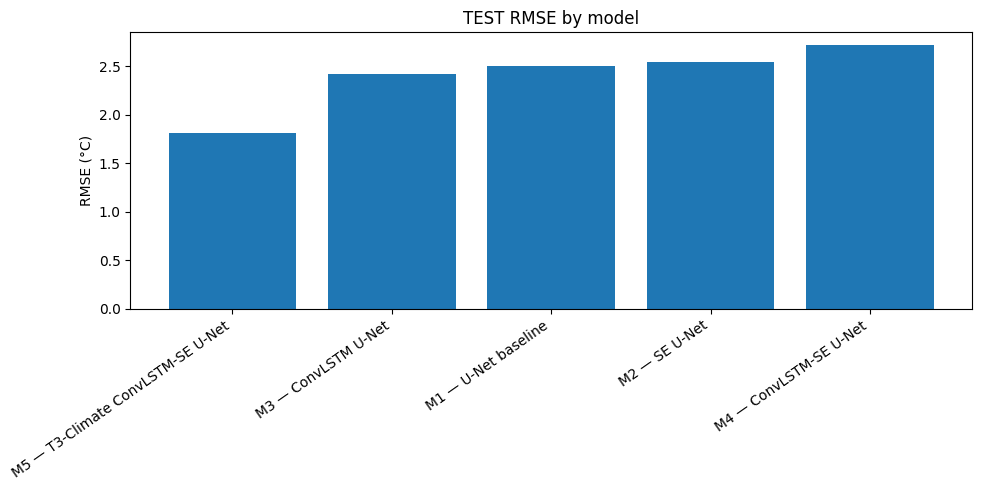

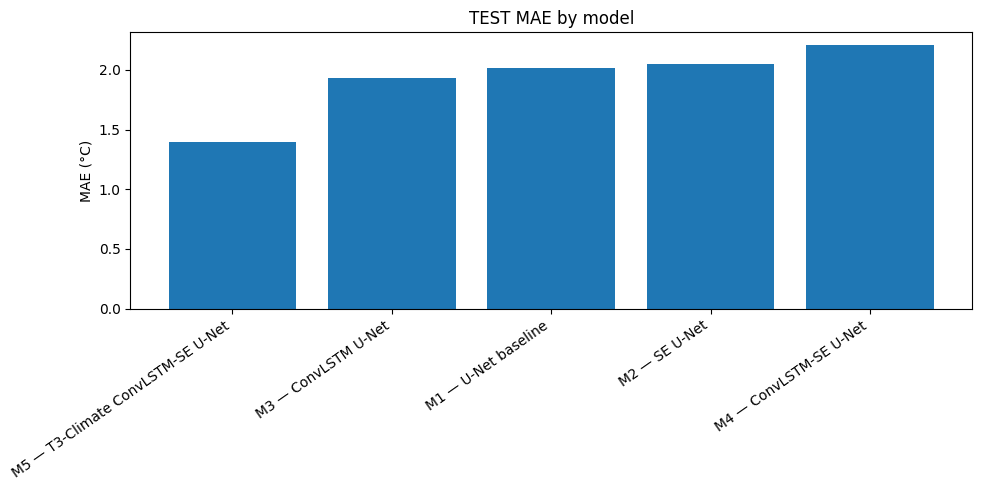

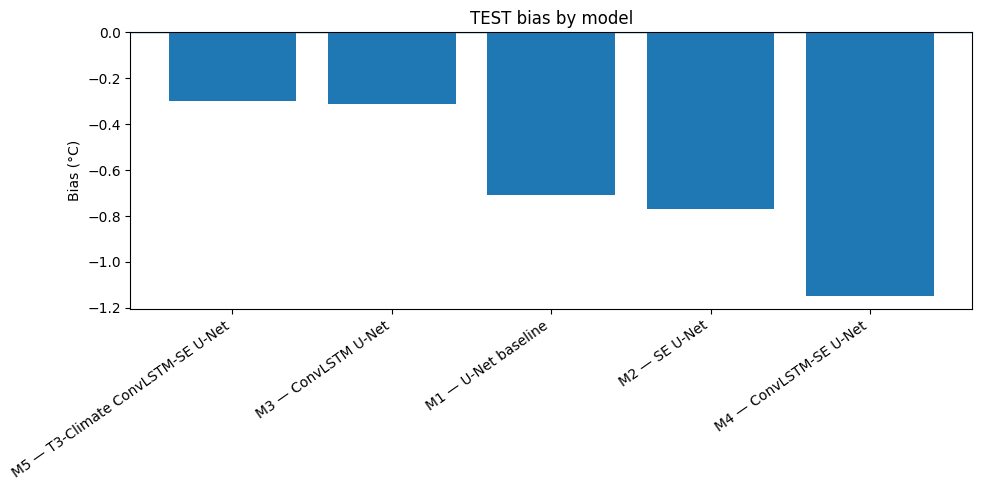

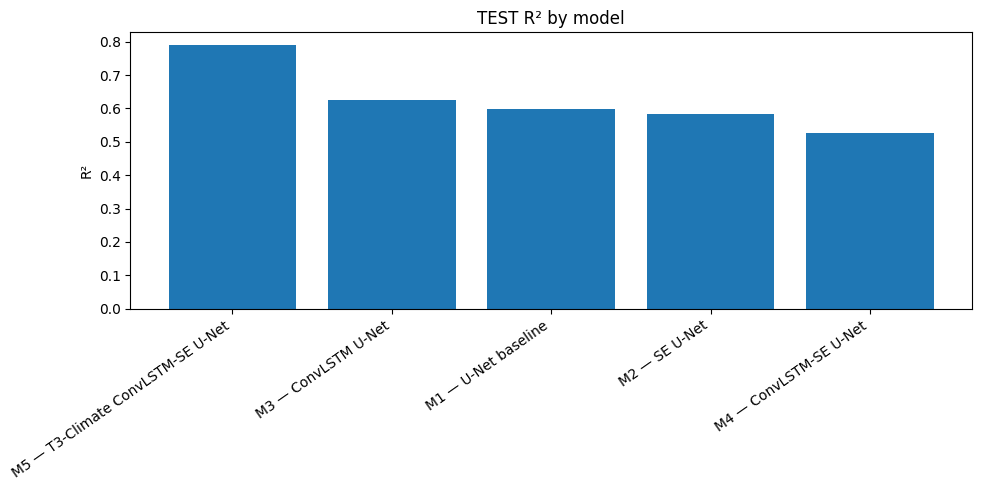

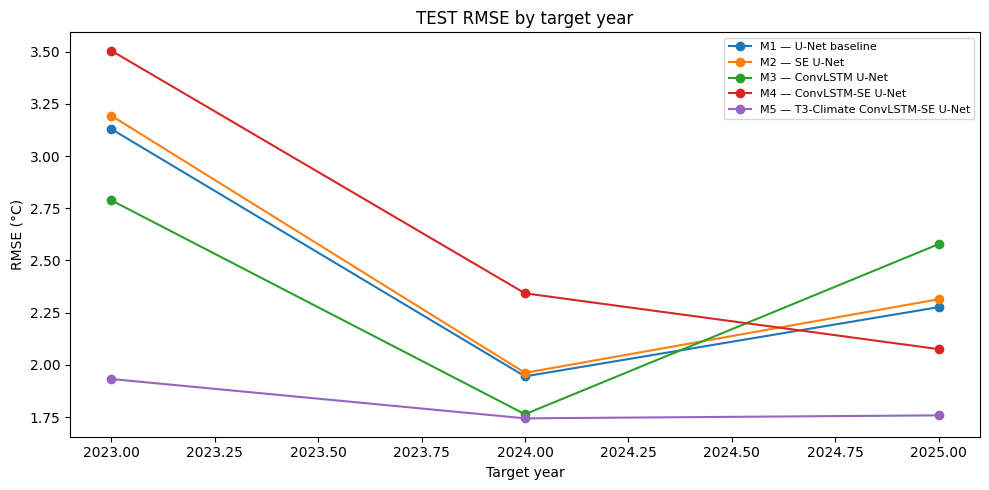

Model-comparison figures saved to: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures


In [ ]:
# ============================================================
# 09 — Manuscript-ready plots for model comparison
# ============================================================

plot_df = test_rank_c.sort_values("rmse_c").copy()
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_label"], plot_df["rmse_c"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("RMSE (°C)")
plt.title("TEST RMSE by model")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_test_rmse_celsius_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

plot_df = test_rank_c.sort_values("mae_c").copy()
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_label"], plot_df["mae_c"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("MAE (°C)")
plt.title("TEST MAE by model")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_test_mae_celsius_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

plot_df = test_rank_c.copy()
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_label"], plot_df["bias_c"])
plt.axhline(0, linewidth=1)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Bias (°C)")
plt.title("TEST bias by model")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_test_bias_celsius_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

plot_df = test_rank_c.sort_values("r2", ascending=False).copy()
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_label"], plot_df["r2"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("R²")
plt.title("TEST R² by model")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_test_r2_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

test_year_c = year_c[year_c["split"].astype(str).str.lower() == "test"].copy()
pivot_rmse_c = test_year_c.pivot_table(
    index="target_year", columns="model_label", values="rmse_c", aggfunc="first"
)

plt.figure(figsize=(10, 5))
for col in pivot_rmse_c.columns:
    plt.plot(pivot_rmse_c.index, pivot_rmse_c[col], marker="o", label=col)
plt.xlabel("Target year")
plt.ylabel("RMSE (°C)")
plt.title("TEST RMSE by target year")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_test_rmse_celsius_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

print("Model-comparison figures saved to:", FIG_DIR)

## Optional raster-based physical exports

The following cells are optional. They run only if the notebook finds an inventory CSV containing either:

1. Celsius rasters:
   - `pred_c_tif`
   - `target_c_tif`

or

2. normalized rasters:
   - `pred_norm_tif`
   - `target_norm_tif`

If normalized rasters are found, this notebook converts them to °C and exports:

- `M5_observed_LST_C_YYYY.tif`
- `M5_predicted_LST_C_YYYY.tif`
- `M5_residual_C_YYYY.tif`
- `M5_abs_error_C_YYYY.tif`

It also generates triptych figures with observed LST, predicted LST and pixel-wise agreement.

In [ ]:
# ============================================================
# 09 — Raster utilities
# ============================================================

def read_raster(path):
    if not RASTERIO_AVAILABLE:
        raise ImportError("rasterio is required for raster operations.")
    path = Path(str(path))
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        nodata = src.nodata
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)
    return arr, profile


def write_raster(path, arr, profile, nodata=-9999.0):
    if not RASTERIO_AVAILABLE:
        raise ImportError("rasterio is required for raster operations.")
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    out = np.array(arr, dtype="float32")
    out = np.where(np.isfinite(out), out, nodata).astype("float32")

    profile = profile.copy()
    profile.update(
        dtype="float32",
        count=1,
        nodata=nodata,
        compress="lzw"
    )

    with rasterio.open(path, "w", **profile) as dst:
        dst.write(out, 1)


def compute_pixel_metrics_celsius(obs_c, pred_c, valid=None):
    if valid is None:
        valid = np.isfinite(obs_c) & np.isfinite(pred_c)
    else:
        valid = valid & np.isfinite(obs_c) & np.isfinite(pred_c)

    y = obs_c[valid].astype("float64")
    p = pred_c[valid].astype("float64")

    if len(y) == 0:
        return {
            "rmse_c": np.nan, "mae_c": np.nan, "bias_c": np.nan,
            "abs_bias_c": np.nan, "r2": np.nan, "r": np.nan, "n_valid_pixels": 0
        }

    err = p - y
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    bias = float(np.mean(err))

    if len(y) > 1 and np.nanvar(y) > 0:
        ss_res = float(np.sum((y - p) ** 2))
        ss_tot = float(np.sum((y - np.mean(y)) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
        r = float(np.corrcoef(y, p)[0, 1])
    else:
        r2 = np.nan
        r = np.nan

    return {
        "rmse_c": rmse,
        "mae_c": mae,
        "bias_c": bias,
        "abs_bias_c": abs(bias),
        "r2": float(r2) if np.isfinite(r2) else np.nan,
        "r": float(r) if np.isfinite(r) else np.nan,
        "n_valid_pixels": int(len(y))
    }


def raster_stats(arr, valid=None):
    if valid is None:
        vals = arr[np.isfinite(arr)]
    else:
        vals = arr[valid & np.isfinite(arr)]

    if len(vals) == 0:
        return {k: np.nan for k in ["min", "p02", "p05", "median", "p95", "p98", "max", "mean", "std"]}

    return {
        "min": float(np.min(vals)),
        "p02": float(np.percentile(vals, 2)),
        "p05": float(np.percentile(vals, 5)),
        "median": float(np.median(vals)),
        "p95": float(np.percentile(vals, 95)),
        "p98": float(np.percentile(vals, 98)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
    }

In [ ]:
# ============================================================
# 09 — Locate raster inventory
# ============================================================

from pathlib import Path
import pandas as pd
import os

# ------------------------------------------------------------
# Defensive directory creation
# ------------------------------------------------------------
# This cell may be executed independently after a kernel restart
# or after changing BASE_OUT/OUTPUT_DIR. Therefore, it recreates
# all required output folders before writing any CSV file.

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = BASE_OUT / "09_physical_unit_evaluation_and_exports"

if "TABLE_DIR" not in globals():
    TABLE_DIR = OUTPUT_DIR / "tables"

if "FIG_DIR" not in globals():
    FIG_DIR = OUTPUT_DIR / "figures"

if "RASTER_DIR" not in globals():
    RASTER_DIR = OUTPUT_DIR / "rasters_celsius"

if "METADATA_DIR" not in globals():
    METADATA_DIR = OUTPUT_DIR / "metadata"

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, RASTER_DIR, METADATA_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Output folders verified:")
print("  OUTPUT_DIR  :", OUTPUT_DIR)
print("  TABLE_DIR   :", TABLE_DIR)
print("  FIG_DIR     :", FIG_DIR)
print("  RASTER_DIR  :", RASTER_DIR)
print("  METADATA_DIR:", METADATA_DIR)


# ------------------------------------------------------------
# Helper: normalize text safely
# ------------------------------------------------------------
if "normalize_text" not in globals():
    def normalize_text(x):
        return str(x).lower().replace("-", "_").replace(" ", "_")


# ------------------------------------------------------------
# Candidate inventory search
# ------------------------------------------------------------
def candidate_inventory_csvs():
    """
    Search for CSV files that may contain raster inventories.

    Expected useful inventories contain either:
    - pred_c_tif and target_c_tif
    - pred_norm_tif and target_norm_tif

    The function first checks an explicit user-defined override.
    Then it searches in controlled project locations.
    """

    candidates = []

    # Explicit path override, if provided
    if "PREDICTION_INVENTORY_CSV_OVERRIDE" in globals() and PREDICTION_INVENTORY_CSV_OVERRIDE:
        p = Path(PREDICTION_INVENTORY_CSV_OVERRIDE).expanduser()
        if p.exists():
            candidates.append(p)
        else:
            raise FileNotFoundError(
                f"PREDICTION_INVENTORY_CSV override does not exist: {p}"
            )

    # Controlled search roots
    search_roots = []

    for name in ["OUTPUT_DIR", "BASE_OUT", "PROJECT_ROOT"]:
        if name in globals():
            p = Path(globals()[name])
            if p.exists():
                search_roots.append(p)

    # Optional: search MyDrive only if project variables did not find candidates
    # This can be slow in very large Google Drive accounts, so it is last.
    mydrive = Path("/content/drive/MyDrive")
    if mydrive.exists():
        search_roots.append(mydrive)

    # Remove duplicates while preserving order
    unique_roots = []
    seen_roots = set()
    for root in search_roots:
        root = Path(root)
        if root not in seen_roots:
            unique_roots.append(root)
            seen_roots.add(root)

    patterns = [
        "*inventory*.csv",
        "*export*.csv",
        "*M5*.csv",
        "*M5B*.csv",
        "*pred*.csv",
        "*prediction*.csv",
        "*celsius*.csv",
        "*verified*.csv",
    ]

    seen_files = set()

    for root in unique_roots:
        if not root.exists():
            continue

        print(f"Searching raster inventory candidates under: {root}")

        for pat in patterns:
            try:
                for p in root.rglob(pat):
                    if not p.is_file():
                        continue

                    # Skip hidden/system folders and previous temporary outputs
                    parts_lower = [part.lower() for part in p.parts]
                    if any(skip in parts_lower for skip in [".trash", ".ipynb_checkpoints"]):
                        continue

                    if p not in seen_files:
                        seen_files.add(p)
                        candidates.append(p)

            except Exception as e:
                print(f"  Warning: could not search pattern {pat} under {root}: {repr(e)}")

    return candidates


# ------------------------------------------------------------
# Inventory classification
# ------------------------------------------------------------
def classify_inventory(path):
    """
    Check whether a CSV file is useful as raster inventory.

    A valid inventory must contain one of these column pairs:
    - pred_c_tif + target_c_tif
    - pred_norm_tif + target_norm_tif
    """

    path = Path(path)

    try:
        df = pd.read_csv(path)
    except Exception:
        return None

    cols = set(df.columns)

    has_celsius = {"pred_c_tif", "target_c_tif"}.issubset(cols)
    has_norm = {"pred_norm_tif", "target_norm_tif"}.issubset(cols)

    if not (has_celsius or has_norm):
        return None

    score = 0

    # Prefer inventories already in physical units
    if has_celsius:
        score += 20

    # Normalized rasters are also valid because this notebook can convert them
    if has_norm:
        score += 10

    # Prefer inventories with explicit temporal metadata
    if "year" in cols:
        score += 5
    if "target_year" in cols:
        score += 5
    if "split" in cols:
        score += 3

    # Prefer files whose names indicate final/verified/M5 products
    name = normalize_text(path.name)
    for token in ["verified", "celsius", "m5", "m5b", "final", "prediction", "export"]:
        if token in name:
            score += 2

    return {
        "path": path,
        "df": df,
        "has_celsius": has_celsius,
        "has_norm": has_norm,
        "score": score,
        "n_rows": len(df),
        "columns": list(df.columns),
    }


# ------------------------------------------------------------
# Run search
# ------------------------------------------------------------
inventory_candidates = []

for p in candidate_inventory_csvs():
    info = classify_inventory(p)
    if info is not None:
        inventory_candidates.append(info)

if inventory_candidates:
    inventory_report = pd.DataFrame([
        {
            "path": str(x["path"]),
            "score": x["score"],
            "has_celsius": x["has_celsius"],
            "has_norm": x["has_norm"],
            "n_rows": x["n_rows"],
            "columns": ", ".join(x["columns"][:20]),
        }
        for x in inventory_candidates
    ]).sort_values("score", ascending=False).reset_index(drop=True)
else:
    inventory_report = pd.DataFrame(
        columns=[
            "path",
            "score",
            "has_celsius",
            "has_norm",
            "n_rows",
            "columns",
        ]
    )


# ------------------------------------------------------------
# Save inventory report safely
# ------------------------------------------------------------
METADATA_DIR.mkdir(parents=True, exist_ok=True)

inventory_report_path = METADATA_DIR / "09_raster_inventory_candidates.csv"
inventory_report.to_csv(inventory_report_path, index=False, encoding="utf-8-sig")

print("\nRaster inventory candidate report saved to:")
print(" ", inventory_report_path)

if len(inventory_report):
    print("\nCandidate raster inventories found:")
    try:
        display(inventory_report.head(20))
    except NameError:
        print(inventory_report.head(20).to_string(index=False))
else:
    print("\nNo raster inventory with pred/target raster paths was found.")
    print("The raster export section will be skipped unless you provide an inventory CSV.")
    print("\nExpected inventory columns:")
    print("  Option A: pred_c_tif, target_c_tif")
    print("  Option B: pred_norm_tif, target_norm_tif")

Output folders verified:
  OUTPUT_DIR  : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports
  TABLE_DIR   : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/tables
  FIG_DIR     : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures
  RASTER_DIR  : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/rasters_celsius
  METADATA_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/metadata
Searching raster inventory candidates under: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Model

,path,score,has_celsius,has_norm,n_rows,columns
0,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/41B_v2_export_m5b_predictions_celsius_M06_verified_2016_2025/41B_v2_m5b_celsius_M06_verified_export_inve...,48,True,True,10,"year, split, pred_norm_tif, target_norm_tif, pred_c_tif, target_c_tif, residual_c_tif, abs_error_c_tif, pred_c_exists, target_c_exists, residual_c_exists, abs_error_c_exists, lst_mu_train, lst_sig..."
1,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/41B_export_m5b_predictions_celsius_if_scaling_available_2016_2025/41B_m5b_celsius_export_inventory_2016_...,46,True,True,10,"year, split, pred_norm_tif, target_norm_tif, pred_c_tif, target_c_tif, residual_c_tif, abs_error_c_tif, pred_c_exists, target_c_exists, residual_c_exists, abs_error_c_exists, lst_mu_train, lst_sig..."
2,/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/41_export_m5b_predictions_full_domain_sliding_window_2016_2025/41_m5b_full_domain_export_inventory_2016_...,44,True,True,10,"year, split, source_npz, pred_norm_tif, target_norm_tif, residual_norm_tif, abs_error_norm_tif, coverage_tif, pred_c_tif, target_c_tif, residual_c_tif, abs_error_c_tif, n_windows, patch_size, stri..."


In [ ]:
# ============================================================
# 09 — Raster export and triptych figures
# ============================================================

from matplotlib.colors import LogNorm, TwoSlopeNorm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# 09 — Figure style configuration
# ============================================================

# QGIS-like LST palette.
# "turbo" is visually close to the blue-green-yellow-red style commonly used
# for LST products, but smoother than classic "jet".
MAP_CMAP = "turbo"

# Pixel-wise agreement palette.
# "turbo" gives visual continuity with the LST maps.
# "viridis" is more conservative; use it if reviewers dislike vivid palettes.
DENSITY_CMAP = "turbo"

# Residual map palette.
# Residuals are signed differences, so a diverging palette centered at zero is correct.
RESIDUAL_CMAP = "RdBu_r"

# Figure behavior
SHOW_FIT_LINE = True       # Shows fitted line together with 1:1 line
SHOW_DISPLAY_NOTE = False  # Avoid clutter inside the panel
EXPORT_SEPARATE_PANELS = True


# ============================================================
# 09 — Helper functions
# ============================================================

def infer_year_from_row(row):
    """
    Infer target year from inventory row.
    Priority:
    1. explicit columns: year, target_year, Y
    2. first year pattern found in path-like strings
    """
    for c in ["year", "target_year", "Y"]:
        if c in row.index and pd.notna(row[c]):
            return int(row[c])

    for v in row.astype(str).values:
        import re
        m = re.search(r"(20[0-9]{2})", v)
        if m:
            return int(m.group(1))

    return None


def prepare_celsius_arrays_from_inventory_row(row):
    """
    Return observed Celsius, predicted Celsius and spatial profile.

    Accepted inventory options:
    A. pred_c_tif + target_c_tif
       Products are already in °C.

    B. pred_norm_tif + target_norm_tif
       Products are normalized and are converted here using:
       LST_C = LST_norm * SIGMA_TRAIN + MU_TRAIN
    """

    if "pred_c_tif" in row.index and "target_c_tif" in row.index:
        pred_path = Path(str(row["pred_c_tif"]))
        target_path = Path(str(row["target_c_tif"]))

        if pred_path.exists() and target_path.exists():
            pred_c, profile = read_raster(pred_path)
            target_c, _ = read_raster(target_path)
            return target_c, pred_c, profile, "celsius_input"

    if "pred_norm_tif" in row.index and "target_norm_tif" in row.index:
        pred_path = Path(str(row["pred_norm_tif"]))
        target_path = Path(str(row["target_norm_tif"]))

        if pred_path.exists() and target_path.exists():
            pred_norm, profile = read_raster(pred_path)
            target_norm, _ = read_raster(target_path)

            pred_c = pred_norm * SIGMA_TRAIN + MU_TRAIN
            target_c = target_norm * SIGMA_TRAIN + MU_TRAIN

            return target_c, pred_c, profile, "normalized_input_converted"

    raise FileNotFoundError("No valid pred/target raster pair found for this row.")


def get_common_display_range(obs_c, pred_c, valid, fixed_map_range=None):
    """
    Common LST display range for observed and predicted maps.
    Uses both observed and predicted values to avoid misleading visual comparison.
    """

    valid_all = valid & np.isfinite(obs_c) & np.isfinite(pred_c)

    obs_v = obs_c[valid_all].astype("float64")
    pred_v = pred_c[valid_all].astype("float64")

    if len(obs_v) == 0:
        raise ValueError("No valid pixels available for display range.")

    if fixed_map_range is not None:
        return fixed_map_range

    vals = np.concatenate([obs_v, pred_v])
    vmin = float(np.percentile(vals, 2))
    vmax = float(np.percentile(vals, 98))

    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin >= vmax):
        vmin = float(np.nanmin(vals))
        vmax = float(np.nanmax(vals))

    return vmin, vmax


def get_agreement_display_range(obs_v, pred_v, agreement_percentiles=(0.5, 99.5)):
    """
    Display range for pixel-wise agreement panel.
    Metrics are still computed outside this function over the full valid domain.
    """

    if agreement_percentiles is None:
        xy_min = float(min(np.nanmin(obs_v), np.nanmin(pred_v)))
        xy_max = float(max(np.nanmax(obs_v), np.nanmax(pred_v)))
        agreement_note = None
    else:
        q_low, q_high = agreement_percentiles
        xy_vals = np.concatenate([obs_v, pred_v])
        xy_min = float(np.percentile(xy_vals, q_low))
        xy_max = float(np.percentile(xy_vals, q_high))
        agreement_note = f"display: p{q_low:g}–p{q_high:g}"

    if (not np.isfinite(xy_min)) or (not np.isfinite(xy_max)) or (xy_min >= xy_max):
        xy_min = float(min(np.nanmin(obs_v), np.nanmin(pred_v)))
        xy_max = float(max(np.nanmax(obs_v), np.nanmax(pred_v)))
        agreement_note = None

    return xy_min, xy_max, agreement_note


# ============================================================
# 09 — Separate panel exports for PowerPoint composition
# ============================================================

def export_map_panel(
    arr_c,
    valid,
    year,
    title,
    out_path,
    cmap_maps=MAP_CMAP,
    vmin=None,
    vmax=None,
    show_title=True
):
    """
    Export a single clean LST map panel without colorbar.
    Useful for assembling multi-panel figures in PowerPoint.
    """

    valid_panel = valid & np.isfinite(arr_c)
    arr_plot = np.where(valid_panel, arr_c, np.nan)

    map_cmap = plt.get_cmap(cmap_maps).copy()
    map_cmap.set_bad("white")

    fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.6), constrained_layout=True)

    ax.imshow(
        arr_plot,
        cmap=map_cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    if show_title:
        ax.set_title(title, fontsize=14)

    ax.axis("off")

    fig.savefig(out_path, dpi=300, bbox_inches="tight", transparent=False)
    plt.show()
    plt.close(fig)


def export_lst_colorbar(
    vmin,
    vmax,
    out_path,
    cmap_maps=MAP_CMAP,
    orientation="horizontal"
):
    """
    Export standalone LST colorbar for PowerPoint composition.
    """

    cmap = plt.get_cmap(cmap_maps)

    if orientation == "horizontal":
        fig, ax = plt.subplots(figsize=(6.5, 0.6), constrained_layout=True)
    else:
        fig, ax = plt.subplots(figsize=(0.8, 5.8), constrained_layout=True)

    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cb = fig.colorbar(sm, cax=ax, orientation=orientation)
    cb.set_label("LST (°C)", fontsize=12)
    cb.ax.tick_params(labelsize=10)

    fig.savefig(out_path, dpi=300, bbox_inches="tight", transparent=True)
    plt.show()
    plt.close(fig)


def export_agreement_panel(
    obs_c,
    pred_c,
    valid,
    year,
    metrics,
    out_path,
    cmap_density=DENSITY_CMAP,
    agreement_percentiles=(0.5, 99.5),
    show_fit_line=SHOW_FIT_LINE,
    show_display_note=SHOW_DISPLAY_NOTE,
):
    """
    Export standalone pixel-wise agreement panel.
    Uses hexbin density, 1:1 line, and optional fitted line.
    """

    valid_all = valid & np.isfinite(obs_c) & np.isfinite(pred_c)

    obs_v = obs_c[valid_all].astype("float64")
    pred_v = pred_c[valid_all].astype("float64")

    if len(obs_v) == 0:
        print(f"No valid pixels for agreement panel year {year}.")
        return

    xy_min, xy_max, agreement_note = get_agreement_display_range(
        obs_v,
        pred_v,
        agreement_percentiles=agreement_percentiles
    )

    display_mask = (
        np.isfinite(obs_v) &
        np.isfinite(pred_v) &
        (obs_v >= xy_min) & (obs_v <= xy_max) &
        (pred_v >= xy_min) & (pred_v <= xy_max)
    )

    obs_h = obs_v[display_mask]
    pred_h = pred_v[display_mask]

    if len(obs_h) == 0:
        obs_h = obs_v
        pred_h = pred_v
        xy_min = float(min(np.nanmin(obs_v), np.nanmin(pred_v)))
        xy_max = float(max(np.nanmax(obs_v), np.nanmax(pred_v)))
        agreement_note = None

    density_cmap = plt.get_cmap(cmap_density).copy()
    density_cmap.set_bad("white")

    fig, ax = plt.subplots(1, 1, figsize=(6.4, 5.8), constrained_layout=True)

    hb = ax.hexbin(
        obs_h,
        pred_h,
        gridsize=90,
        mincnt=1,
        cmap=density_cmap,
        norm=LogNorm(),
        linewidths=0.0
    )

    # 1:1 reference line
    ax.plot(
        [xy_min, xy_max],
        [xy_min, xy_max],
        linestyle="--",
        linewidth=1.2,
        color="0.30",
        label="1:1"
    )

    # Optional fitted line
    if show_fit_line:
        try:
            if len(obs_h) > 2:
                slope, intercept = np.polyfit(obs_h, pred_h, 1)
                xfit = np.linspace(xy_min, xy_max, 200)
                yfit = slope * xfit + intercept

                ax.plot(
                    xfit,
                    yfit,
                    linewidth=1.2,
                    color="crimson",
                    label=f"Fit: y={slope:.2f}x+{intercept:.2f}"
                )
        except Exception:
            pass

    ax.set_xlim(xy_min, xy_max)
    ax.set_ylim(xy_min, xy_max)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Observed LST (°C)", fontsize=11)
    ax.set_ylabel("Predicted LST (°C)", fontsize=11)
    ax.set_title(f"Pixel-wise agreement {year}", fontsize=13)

    ax.grid(alpha=0.18, linewidth=0.5)
    ax.tick_params(labelsize=10)

    r2 = metrics.get("r2", np.nan)
    rmse = metrics.get("rmse_c", np.nan)
    mae = metrics.get("mae_c", np.nan)
    bias = metrics.get("bias_c", np.nan)
    n_valid = metrics.get("n_valid_pixels", len(obs_v))

    txt = (
        f"$R^2$ = {r2:.3f}\n"
        f"RMSE = {rmse:.2f} °C\n"
        f"MAE = {mae:.2f} °C\n"
        f"Bias = {bias:.2f} °C\n"
        f"n = {n_valid:,}"
    )

    ax.text(
        0.04,
        0.96,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10.5,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.93
        )
    )

    if show_display_note and agreement_note is not None:
        ax.text(
            0.04,
            0.04,
            agreement_note,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=9,
            color="0.30"
        )

    ax.legend(
        loc="lower right",
        fontsize=8.5,
        frameon=True,
        framealpha=0.88
    )

    cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label("Pixel count (log scale)", fontsize=10)
    cb.ax.tick_params(labelsize=9)

    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 09 — Triptych figure
# ============================================================

def plot_triptych(
    obs_c,
    pred_c,
    valid,
    year,
    metrics,
    out_path,
    cmap_maps=MAP_CMAP,
    cmap_density=DENSITY_CMAP,
    fixed_map_range=None,
    agreement_percentiles=(0.5, 99.5),
    show_fit_line=SHOW_FIT_LINE,
    show_display_note=SHOW_DISPLAY_NOTE,
):
    """
    Manuscript-ready triptych figure:

    (a) Observed LST in °C
    (b) Predicted LST in °C
    (c) Pixel-wise agreement using hexagonal density
    """

    valid_all = valid & np.isfinite(obs_c) & np.isfinite(pred_c)

    obs_v = obs_c[valid_all].astype("float64")
    pred_v = pred_c[valid_all].astype("float64")

    if len(obs_v) == 0:
        print(f"No valid pixels for triptych year {year}.")
        return

    vmin, vmax = get_common_display_range(
        obs_c,
        pred_c,
        valid,
        fixed_map_range=fixed_map_range
    )

    obs_plot = np.where(valid_all, obs_c, np.nan)
    pred_plot = np.where(valid_all, pred_c, np.nan)

    xy_min, xy_max, agreement_note = get_agreement_display_range(
        obs_v,
        pred_v,
        agreement_percentiles=agreement_percentiles
    )

    display_mask = (
        np.isfinite(obs_v) &
        np.isfinite(pred_v) &
        (obs_v >= xy_min) & (obs_v <= xy_max) &
        (pred_v >= xy_min) & (pred_v <= xy_max)
    )

    obs_h = obs_v[display_mask]
    pred_h = pred_v[display_mask]

    if len(obs_h) == 0:
        obs_h = obs_v
        pred_h = pred_v
        xy_min = float(min(np.nanmin(obs_v), np.nanmin(pred_v)))
        xy_max = float(max(np.nanmax(obs_v), np.nanmax(pred_v)))
        agreement_note = None

    map_cmap = plt.get_cmap(cmap_maps).copy()
    map_cmap.set_bad("white")

    density_cmap = plt.get_cmap(cmap_density).copy()
    density_cmap.set_bad("white")

    fig = plt.figure(figsize=(18.5, 5.6), constrained_layout=True)

    gs = fig.add_gridspec(
        nrows=1,
        ncols=4,
        width_ratios=[1.0, 1.0, 0.045, 1.18],
        wspace=0.06
    )

    ax_obs = fig.add_subplot(gs[0, 0])
    ax_pred = fig.add_subplot(gs[0, 1])
    cax_map = fig.add_subplot(gs[0, 2])
    ax_agree = fig.add_subplot(gs[0, 3])

    im_obs = ax_obs.imshow(
        obs_plot,
        cmap=map_cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )
    ax_obs.set_title(f"(a) Observed LST {year} (°C)", fontsize=13)
    ax_obs.axis("off")

    im_pred = ax_pred.imshow(
        pred_plot,
        cmap=map_cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )
    ax_pred.set_title(f"(b) Predicted LST {year} (°C)", fontsize=13)
    ax_pred.axis("off")

    cb_map = fig.colorbar(im_pred, cax=cax_map)
    cb_map.set_label("LST (°C)", fontsize=11)
    cb_map.ax.tick_params(labelsize=10)

    hb = ax_agree.hexbin(
        obs_h,
        pred_h,
        gridsize=90,
        mincnt=1,
        cmap=density_cmap,
        norm=LogNorm(),
        linewidths=0.0
    )

    ax_agree.plot(
        [xy_min, xy_max],
        [xy_min, xy_max],
        linestyle="--",
        linewidth=1.2,
        color="0.30",
        label="1:1"
    )

    if show_fit_line:
        try:
            if len(obs_h) > 2:
                slope, intercept = np.polyfit(obs_h, pred_h, 1)
                xfit = np.linspace(xy_min, xy_max, 200)
                yfit = slope * xfit + intercept

                ax_agree.plot(
                    xfit,
                    yfit,
                    linewidth=1.2,
                    color="crimson",
                    label=f"Fit: y={slope:.2f}x+{intercept:.2f}"
                )
        except Exception:
            pass

    ax_agree.set_xlim(xy_min, xy_max)
    ax_agree.set_ylim(xy_min, xy_max)
    ax_agree.set_aspect("equal", adjustable="box")

    ax_agree.set_xlabel("Observed LST (°C)", fontsize=11)
    ax_agree.set_ylabel("Predicted LST (°C)", fontsize=11)
    ax_agree.set_title("(c) Pixel-wise agreement", fontsize=13)

    ax_agree.grid(alpha=0.18, linewidth=0.5)
    ax_agree.tick_params(labelsize=10)

    r2 = metrics.get("r2", np.nan)
    rmse = metrics.get("rmse_c", np.nan)
    mae = metrics.get("mae_c", np.nan)
    bias = metrics.get("bias_c", np.nan)
    n_valid = metrics.get("n_valid_pixels", len(obs_v))

    txt = (
        f"$R^2$ = {r2:.3f}\n"
        f"RMSE = {rmse:.2f} °C\n"
        f"MAE = {mae:.2f} °C\n"
        f"Bias = {bias:.2f} °C\n"
        f"n = {n_valid:,}"
    )

    ax_agree.text(
        0.04,
        0.96,
        txt,
        transform=ax_agree.transAxes,
        ha="left",
        va="top",
        fontsize=10.5,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="0.45",
            alpha=0.93
        )
    )

    if show_display_note and agreement_note is not None:
        ax_agree.text(
            0.04,
            0.04,
            agreement_note,
            transform=ax_agree.transAxes,
            ha="left",
            va="bottom",
            fontsize=9,
            color="0.30"
        )

    ax_agree.legend(
        loc="lower right",
        fontsize=8.5,
        frameon=True,
        framealpha=0.88
    )

    cb_density = fig.colorbar(hb, ax=ax_agree, fraction=0.046, pad=0.03)
    cb_density.set_label("Pixel count (log scale)", fontsize=10)
    cb_density.ax.tick_params(labelsize=9)

    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 09 — Residual map
# ============================================================

def plot_residual_map(
    residual_c,
    valid,
    year,
    out_path,
    cmap_residual=RESIDUAL_CMAP,
    residual_percentile=98
):
    """
    Manuscript-ready residual map.

    Residual definition:
        residual = predicted LST - observed LST

    Positive values indicate overestimation.
    Negative values indicate underestimation.
    """

    valid_res = valid & np.isfinite(residual_c)
    vals = residual_c[valid_res]

    if len(vals) == 0:
        print(f"No valid residual pixels for year {year}.")
        return

    lim = float(np.percentile(np.abs(vals), residual_percentile))

    if (not np.isfinite(lim)) or (lim <= 0):
        lim = float(np.nanmax(np.abs(vals)))

    residual_plot = np.where(valid_res, residual_c, np.nan)

    res_cmap = plt.get_cmap(cmap_residual).copy()
    res_cmap.set_bad("white")

    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    fig, ax = plt.subplots(
        1,
        1,
        figsize=(7.2, 5.8),
        constrained_layout=True
    )

    im = ax.imshow(
        residual_plot,
        cmap=res_cmap,
        norm=norm,
        interpolation="nearest"
    )

    ax.set_title(
        f"Residual map {year}: predicted - observed (°C)",
        fontsize=13
    )

    ax.axis("off")

    cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.025)
    cb.set_label("Residual (°C)", fontsize=11)
    cb.ax.tick_params(labelsize=10)

    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 09 — Raster export and figure generation
# ============================================================

raster_metrics_records = []
raster_stats_records = []
raster_inventory_records = []

if RASTERIO_AVAILABLE and inventory_candidates:
    selected = sorted(
        inventory_candidates,
        key=lambda x: x["score"],
        reverse=True
    )[0]

    inv_path = selected["path"]
    inv_df = selected["df"].copy()

    print("Selected raster inventory:")
    print(inv_path)
    print("Columns:", list(inv_df.columns))

    rows = []

    for _, row in inv_df.iterrows():
        year = infer_year_from_row(row)

        if year in ALL_YEARS:
            row = row.copy()
            row["year_inferred"] = year
            rows.append(row)

    if not rows:
        print("No rows for 2016–2025 found in selected inventory. Raster processing skipped.")

    else:
        proc_df = (
            pd.DataFrame(rows)
            .sort_values("year_inferred")
            .reset_index(drop=True)
        )

        for _, row in proc_df.iterrows():
            year = int(row["year_inferred"])
            split = SPLIT_MAP.get(year, "unknown")

            print(f"\nProcessing year {year} ({split})...")

            try:
                obs_c, pred_c, profile, source_mode = prepare_celsius_arrays_from_inventory_row(row)

            except Exception as e:
                print(f"  Skipped year {year}: {repr(e)}")
                continue

            valid = np.isfinite(obs_c) & np.isfinite(pred_c)

            residual_c = np.where(
                valid,
                pred_c - obs_c,
                np.nan
            ).astype("float32")

            abs_error_c = np.where(
                valid,
                np.abs(pred_c - obs_c),
                np.nan
            ).astype("float32")

            metrics = compute_pixel_metrics_celsius(
                obs_c,
                pred_c,
                valid=valid
            )

            metrics.update({
                "year": year,
                "split": split,
                "source_mode": source_mode,
                "lst_mu_train_c": MU_TRAIN,
                "lst_sigma_train_c": SIGMA_TRAIN,
            })

            raster_metrics_records.append(metrics)

            # ------------------------------------------------
            # Export rasters
            # ------------------------------------------------
            obs_path = RASTER_DIR / f"M5_observed_LST_C_{year}.tif"
            pred_path = RASTER_DIR / f"M5_predicted_LST_C_{year}.tif"
            residual_path = RASTER_DIR / f"M5_residual_C_{year}.tif"
            abs_error_path = RASTER_DIR / f"M5_abs_error_C_{year}.tif"

            write_raster(obs_path, obs_c, profile)
            write_raster(pred_path, pred_c, profile)
            write_raster(residual_path, residual_c, profile)
            write_raster(abs_error_path, abs_error_c, profile)

            raster_inventory_records.append({
                "year": year,
                "split": split,
                "observed_c_tif": str(obs_path),
                "predicted_c_tif": str(pred_path),
                "residual_c_tif": str(residual_path),
                "abs_error_c_tif": str(abs_error_path),
                "source_mode": source_mode,
            })

            # ------------------------------------------------
            # Raster statistics
            # ------------------------------------------------
            for product_name, arr in [
                ("observed_c", obs_c),
                ("predicted_c", pred_c),
                ("residual_c", residual_c),
                ("abs_error_c", abs_error_c),
            ]:
                stats = raster_stats(arr, valid=np.isfinite(arr))

                stats.update({
                    "year": year,
                    "split": split,
                    "product": product_name,
                })

                raster_stats_records.append(stats)

            # ------------------------------------------------
            # Common map scale for all exported visual panels
            # ------------------------------------------------
            vmin, vmax = get_common_display_range(
                obs_c=obs_c,
                pred_c=pred_c,
                valid=valid,
                fixed_map_range=None
            )

            # ------------------------------------------------
            # Complete triptych
            # ------------------------------------------------
            plot_triptych(
                obs_c=obs_c,
                pred_c=pred_c,
                valid=valid,
                year=year,
                metrics=metrics,
                out_path=FIG_DIR / f"09_M5_triptych_observed_predicted_agreement_{year}.png",
                cmap_maps=MAP_CMAP,
                cmap_density=DENSITY_CMAP,
                fixed_map_range=(vmin, vmax),
                agreement_percentiles=(0.5, 99.5),
                show_fit_line=SHOW_FIT_LINE,
                show_display_note=SHOW_DISPLAY_NOTE,
            )

            # ------------------------------------------------
            # Separate panels for PowerPoint composition
            # ------------------------------------------------
            if EXPORT_SEPARATE_PANELS:
                panel_dir = FIG_DIR / "powerpoint_panels"
                panel_dir.mkdir(parents=True, exist_ok=True)

                export_map_panel(
                    arr_c=obs_c,
                    valid=valid,
                    year=year,
                    title=f"Observed LST {year} (°C)",
                    out_path=panel_dir / f"09_M5_panel_observed_LST_C_{year}.png",
                    cmap_maps=MAP_CMAP,
                    vmin=vmin,
                    vmax=vmax,
                    show_title=True
                )

                export_map_panel(
                    arr_c=pred_c,
                    valid=valid,
                    year=year,
                    title=f"Predicted LST {year} (°C)",
                    out_path=panel_dir / f"09_M5_panel_predicted_LST_C_{year}.png",
                    cmap_maps=MAP_CMAP,
                    vmin=vmin,
                    vmax=vmax,
                    show_title=True
                )

                export_lst_colorbar(
                    vmin=vmin,
                    vmax=vmax,
                    out_path=panel_dir / f"09_M5_colorbar_LST_C_{year}.png",
                    cmap_maps=MAP_CMAP,
                    orientation="horizontal"
                )

                export_agreement_panel(
                    obs_c=obs_c,
                    pred_c=pred_c,
                    valid=valid,
                    year=year,
                    metrics=metrics,
                    out_path=panel_dir / f"09_M5_panel_agreement_{year}.png",
                    cmap_density=DENSITY_CMAP,
                    agreement_percentiles=(0.5, 99.5),
                    show_fit_line=SHOW_FIT_LINE,
                    show_display_note=SHOW_DISPLAY_NOTE,
                )

            # ------------------------------------------------
            # Residual map
            # ------------------------------------------------
            plot_residual_map(
                residual_c=residual_c,
                valid=valid,
                year=year,
                out_path=FIG_DIR / f"09_M5_residual_map_{year}.png",
                cmap_residual=RESIDUAL_CMAP,
                residual_percentile=98
            )

        # ----------------------------------------------------
        # Export raster-derived summaries
        # ----------------------------------------------------
        if raster_metrics_records:
            raster_metrics_df = (
                pd.DataFrame(raster_metrics_records)
                .sort_values("year")
            )

            raster_inventory_df = (
                pd.DataFrame(raster_inventory_records)
                .sort_values("year")
            )

            raster_stats_df = (
                pd.DataFrame(raster_stats_records)
                .sort_values(["year", "product"])
            )

            raster_metrics_path = TABLE_DIR / "09_M5_raster_metrics_by_year_celsius.csv"
            raster_inventory_path = TABLE_DIR / "09_M5_celsius_raster_inventory.csv"
            raster_stats_path = TABLE_DIR / "09_M5_celsius_raster_statistics.csv"

            raster_metrics_df.to_csv(
                raster_metrics_path,
                index=False,
                encoding="utf-8-sig"
            )

            raster_inventory_df.to_csv(
                raster_inventory_path,
                index=False,
                encoding="utf-8-sig"
            )

            raster_stats_df.to_csv(
                raster_stats_path,
                index=False,
                encoding="utf-8-sig"
            )

            print("\nRaster-derived outputs saved:")
            print(" ", raster_metrics_path)
            print(" ", raster_inventory_path)
            print(" ", raster_stats_path)

            try:
                display(raster_metrics_df)
            except NameError:
                print(raster_metrics_df.to_string(index=False))

else:
    print("Raster export section skipped.")
    print("Reason: rasterio unavailable or no suitable raster inventory found.")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# 09 — Final summary for manuscript use
# ============================================================

summary = {
    "module": "09_physical_unit_evaluation_and_exports",
    "status": "completed",
    "project_root": str(PROJECT_ROOT),
    "base_out": str(BASE_OUT),
    "output_dir": str(OUTPUT_DIR),
    "mu_train_c": MU_TRAIN,
    "sigma_train_c": SIGMA_TRAIN,
    "metric_tables": {
        "model_comparison_by_split_celsius": str(split_c_path),
        "model_comparison_by_year_celsius": str(year_c_path),
        "test_ranking_celsius": str(test_rank_path),
        "key_model_comparisons_celsius": str(key_comp_path),
        "workbook": str(excel_path),
    },
    "figures_dir": str(FIG_DIR),
    "rasters_dir": str(RASTER_DIR),
    "raster_products_generated": bool(len(raster_metrics_records) > 0),
    "notes": [
        "This module does not retrain or tune any model.",
        "RMSE, MAE and bias are converted to Celsius using train-only sigma.",
        "R2 is unchanged under the inverse z-score transformation.",
        "TEST ranking is final evaluation only, not model selection."
    ],
}

if len(test_rank_c):
    best_test = test_rank_c.iloc[0]
    summary["best_test_rank_by_rmse_c"] = {
        "model": str(best_test["model"]),
        "model_label": str(best_test["model_label"]),
        "rmse_c": float(best_test["rmse_c"]),
        "mae_c": float(best_test["mae_c"]),
        "bias_c": float(best_test["bias_c"]),
        "r2": float(best_test["r2"]),
        "n_valid_pixels": int(best_test["n_valid_pixels"]),
    }

summary_path = METADATA_DIR / "09_final_findings_summary.json"
save_json(summary_path, summary)

print("Final summary:")
print(json.dumps(summary, indent=2, ensure_ascii=False))
print("\nAll outputs saved under:")
print(OUTPUT_DIR)

Final summary:
{
  "module": "09_physical_unit_evaluation_and_exports",
  "status": "completed",
  "project_root": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling",
  "base_out": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025",
  "output_dir": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports",
  "mu_train_c": 38.48322677612305,
  "sigma_train_c": 4.032179355621338,
  "metric_tables": {
    "model_comparison_by_split_celsius": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/tables/09_model_comparison_by_split_celsius.csv",
    "model_comparison_by_year_celsius": "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_expo

Manuscript year: 2023
Observed raster : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/rasters_celsius/M5_observed_LST_C_2023.tif
Predicted raster: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/rasters_celsius/M5_predicted_LST_C_2023.tif
CRS             : EPSG:32618
LST range       : 31.0 46.5
Metrics         : {'rmse_c': 1.8675326806291648, 'mae_c': 1.461663258232292, 'bias_c': 0.1803369114181306, 'r2': 0.7919754360004528, 'r': 0.8941365228385902, 'n_valid_pixels': 905388}


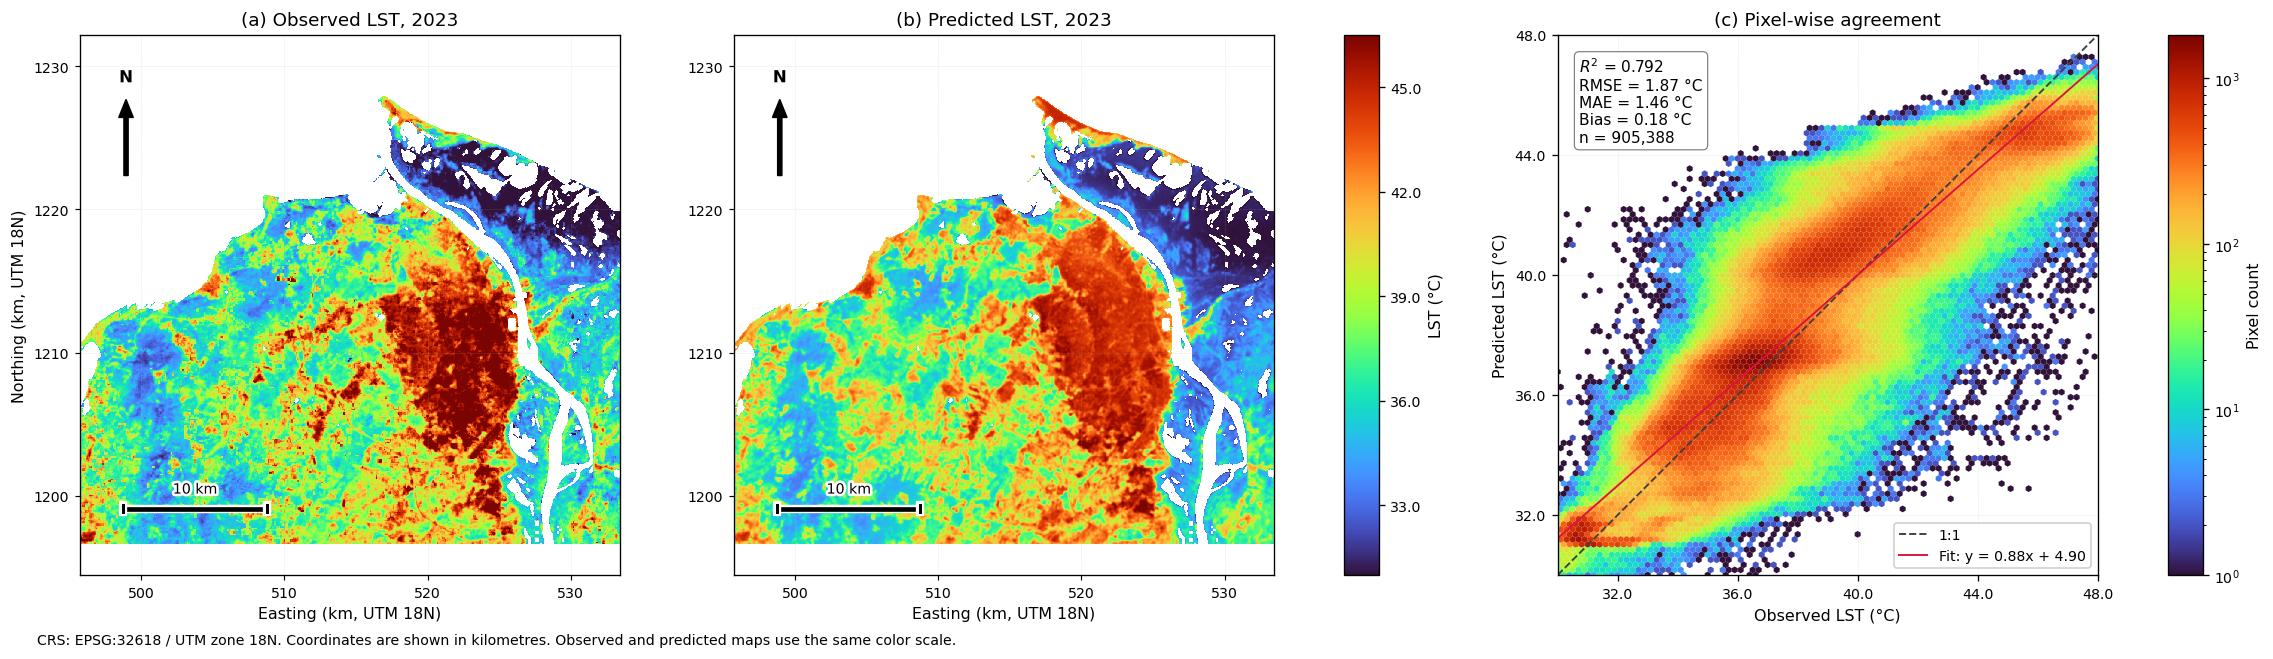

Manuscript figure exported:
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09X_M5_Q1_manuscript_observed_predicted_agreement_2023.png
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09X_M5_Q1_manuscript_observed_predicted_agreement_2023.pdf
Metadata:
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09X_M5_Q1_manuscript_figure_metadata_2023.json


In [ ]:
# ============================================================
# 09X — Manuscript-ready Q1 figure (Observed / Predicted / Agreement)
# Project: Barranquilla LST/SUHI
# Model: M5 / T3-Climate ConvLSTM-SE U-Net
#
# Panels:
# (a) Observed LST
# (b) Predicted LST
# (c) Pixel-wise agreement
#
# Notes:
# - Keeps the project palette for LST and agreement density: turbo
# - Observed and Predicted use the same LST color scale
# - North arrow + scale bar included in BOTH map panels
# - Agreement panel separated further from the maps
# - North arrow moved to the LEFT side of the map panels
# ============================================================

from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.transform import array_bounds

from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter, FormatStrFormatter, MaxNLocator
import matplotlib.patheffects as pe


# ------------------------------------------------------------
# User configuration
# ------------------------------------------------------------

MANUSCRIPT_YEAR = 2023

MAP_CMAP = "turbo"
DENSITY_CMAP = "turbo"

EXPORT_DPI = 600

MANUSCRIPT_FIG_DIR = FIG_DIR / "manuscript_q1"
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)

OBS_TIF = RASTER_DIR / f"M5_observed_LST_C_{MANUSCRIPT_YEAR}.tif"
PRED_TIF = RASTER_DIR / f"M5_predicted_LST_C_{MANUSCRIPT_YEAR}.tif"

METRICS_CSV = TABLE_DIR / "09_M5_raster_metrics_by_year_celsius.csv"

OUT_PNG = MANUSCRIPT_FIG_DIR / (
    f"09X_M5_Q1_manuscript_observed_predicted_agreement_{MANUSCRIPT_YEAR}.png"
)

OUT_PDF = MANUSCRIPT_FIG_DIR / (
    f"09X_M5_Q1_manuscript_observed_predicted_agreement_{MANUSCRIPT_YEAR}.pdf"
)

OUT_META = MANUSCRIPT_FIG_DIR / (
    f"09X_M5_Q1_manuscript_figure_metadata_{MANUSCRIPT_YEAR}.json"
)


# ------------------------------------------------------------
# General plotting style
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5,
    "figure.dpi": 120,
    "savefig.dpi": EXPORT_DPI,
})


# ------------------------------------------------------------
# Raster utilities
# ------------------------------------------------------------

def read_single_band_raster(path):
    """Read a single-band raster and convert nodata to NaN."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Raster not found: {path}")

    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)

    return arr, profile, transform, crs


def raster_extent_from_profile(profile):
    """Return Matplotlib extent [west, east, south, north]."""
    transform = profile["transform"]
    height = profile["height"]
    width = profile["width"]

    west, south, east, north = array_bounds(height, width, transform)
    return [west, east, south, north]


def compute_metrics_celsius(obs_c, pred_c, valid=None):
    """Compute full-domain pixel-wise metrics in °C."""
    if valid is None:
        valid = np.isfinite(obs_c) & np.isfinite(pred_c)
    else:
        valid = valid & np.isfinite(obs_c) & np.isfinite(pred_c)

    y = obs_c[valid].astype("float64")
    p = pred_c[valid].astype("float64")

    if len(y) == 0:
        return {
            "rmse_c": np.nan,
            "mae_c": np.nan,
            "bias_c": np.nan,
            "r2": np.nan,
            "r": np.nan,
            "n_valid_pixels": 0,
        }

    err = p - y
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    bias = float(np.mean(err))

    ss_res = float(np.sum((y - p) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    r = float(np.corrcoef(y, p)[0, 1]) if len(y) > 1 else np.nan

    return {
        "rmse_c": rmse,
        "mae_c": mae,
        "bias_c": bias,
        "r2": float(r2) if np.isfinite(r2) else np.nan,
        "r": float(r) if np.isfinite(r) else np.nan,
        "n_valid_pixels": int(len(y)),
    }


def load_metrics_for_year(year, obs_c, pred_c, valid):
    """
    Prefer the notebook 09 metrics table if available.
    Otherwise compute metrics directly from the rasters.
    """
    metrics = compute_metrics_celsius(obs_c, pred_c, valid=valid)

    if METRICS_CSV.exists():
        df = pd.read_csv(METRICS_CSV)

        if "year" in df.columns:
            row = df.loc[df["year"].astype(int) == int(year)]

            if len(row):
                row = row.iloc[0].to_dict()

                for k in ["rmse_c", "mae_c", "bias_c", "r2", "r", "n_valid_pixels"]:
                    if k in row and pd.notna(row[k]):
                        metrics[k] = row[k]

    return metrics


# ------------------------------------------------------------
# Display range utilities
# ------------------------------------------------------------

def rounded_lST_range(obs_c, pred_c, valid, p_low=2, p_high=98):
    """
    Common LST display range for observed and predicted maps.
    Rounded to 0.5 °C to avoid artificial precision.
    """
    vals = np.concatenate([
        obs_c[valid & np.isfinite(obs_c)].ravel(),
        pred_c[valid & np.isfinite(pred_c)].ravel()
    ])

    vmin = float(np.percentile(vals, p_low))
    vmax = float(np.percentile(vals, p_high))

    vmin = math.floor(vmin * 2.0) / 2.0
    vmax = math.ceil(vmax * 2.0) / 2.0

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin = float(np.nanmin(vals))
        vmax = float(np.nanmax(vals))

    return vmin, vmax


def agreement_display_range(obs_c, pred_c, valid, p_low=0.5, p_high=99.5):
    """
    Display range for agreement panel.
    Metrics are still computed over all valid pixels.
    """
    obs_v = obs_c[valid].astype("float64")
    pred_v = pred_c[valid].astype("float64")

    vals = np.concatenate([obs_v, pred_v])

    xy_min = float(np.percentile(vals, p_low))
    xy_max = float(np.percentile(vals, p_high))

    xy_min = math.floor(xy_min * 2.0) / 2.0
    xy_max = math.ceil(xy_max * 2.0) / 2.0

    if not np.isfinite(xy_min) or not np.isfinite(xy_max) or xy_min >= xy_max:
        xy_min = float(np.nanmin(vals))
        xy_max = float(np.nanmax(vals))

    return xy_min, xy_max


# ------------------------------------------------------------
# Cartographic helpers
# ------------------------------------------------------------

def km_formatter(x, pos):
    """Format projected coordinates as kilometres."""
    return f"{x / 1000:.0f}"


def style_map_axis(ax, extent, show_ylabel=True):
    """Apply map coordinates, grid, equal aspect, and square panel."""
    west, east, south, north = extent

    ax.set_xlim(west, east)
    ax.set_ylim(south, north)
    ax.set_aspect("equal", adjustable="box")
    ax.set_box_aspect(1)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    ax.xaxis.set_major_formatter(FuncFormatter(km_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(km_formatter))

    ax.set_xlabel("Easting (km, UTM 18N)")

    if show_ylabel:
        ax.set_ylabel("Northing (km, UTM 18N)")
    else:
        ax.set_ylabel("")

    ax.grid(True, linestyle=":", linewidth=0.35, alpha=0.55)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=3,
        width=0.7
    )


def nice_scale_length_m(width_m):
    """Choose a reasonable scale-bar length in metres."""
    target = width_m * 0.25
    candidates = np.array([1000, 2000, 5000, 10000, 15000, 20000, 25000, 50000], dtype=float)
    idx = int(np.argmin(np.abs(candidates - target)))
    return float(candidates[idx])


def add_scale_bar(ax, extent, length_m=None, location=(0.08, 0.075)):
    """Add a metric scale bar in data coordinates."""
    west, east, south, north = extent
    width_m = east - west
    height_m = north - south

    if length_m is None:
        length_m = nice_scale_length_m(width_m)

    x0 = west + location[0] * width_m
    y0 = south + location[1] * height_m
    x1 = x0 + length_m

    line_effect = [
        pe.Stroke(linewidth=5.0, foreground="white"),
        pe.Normal()
    ]

    ax.plot([x0, x1], [y0, y0],
            color="black", linewidth=2.8, solid_capstyle="butt",
            path_effects=line_effect, zorder=20)

    ax.plot([x0, x0], [y0 - 0.008 * height_m, y0 + 0.008 * height_m],
            color="black", linewidth=1.8, path_effects=line_effect, zorder=20)

    ax.plot([x1, x1], [y0 - 0.008 * height_m, y0 + 0.008 * height_m],
            color="black", linewidth=1.8, path_effects=line_effect, zorder=20)

    label = f"{int(length_m / 1000)} km"

    ax.text(
        x0 + length_m / 2.0,
        y0 + 0.025 * height_m,
        label,
        ha="center",
        va="bottom",
        fontsize=8.5,
        color="black",
        path_effects=[pe.Stroke(linewidth=3.2, foreground="white"), pe.Normal()],
        zorder=21
    )


def add_north_arrow(ax, location=(0.085, 0.88)):
    """
    Add a north arrow in axes-fraction coordinates.
    Moved to the LEFT side of the map panels.
    """
    x, y = location

    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - 0.14),
        xycoords="axes fraction",
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=2.4,
            headwidth=8.5,
            headlength=10.5
        ),
        zorder=30
    )

    ax.text(
        x,
        y + 0.025,
        "N",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
        path_effects=[pe.Stroke(linewidth=3.0, foreground="white"), pe.Normal()],
        zorder=31
    )


# ------------------------------------------------------------
# Load rasters
# ------------------------------------------------------------

obs_c, obs_profile, obs_transform, obs_crs = read_single_band_raster(OBS_TIF)
pred_c, pred_profile, pred_transform, pred_crs = read_single_band_raster(PRED_TIF)

if obs_c.shape != pred_c.shape:
    raise ValueError(
        f"Observed and predicted rasters have different shapes: "
        f"{obs_c.shape} vs {pred_c.shape}"
    )

valid = np.isfinite(obs_c) & np.isfinite(pred_c)

extent = raster_extent_from_profile(obs_profile)

metrics = load_metrics_for_year(
    MANUSCRIPT_YEAR,
    obs_c=obs_c,
    pred_c=pred_c,
    valid=valid
)

vmin, vmax = rounded_lST_range(obs_c, pred_c, valid, p_low=2, p_high=98)
xy_min, xy_max = agreement_display_range(obs_c, pred_c, valid, p_low=0.5, p_high=99.5)

print("Manuscript year:", MANUSCRIPT_YEAR)
print("Observed raster :", OBS_TIF)
print("Predicted raster:", PRED_TIF)
print("CRS             :", obs_crs)
print("LST range       :", vmin, vmax)
print("Metrics         :", metrics)


# ------------------------------------------------------------
# Prepare arrays for plotting
# ------------------------------------------------------------

obs_plot = np.where(valid, obs_c, np.nan)
pred_plot = np.where(valid, pred_c, np.nan)

map_cmap = plt.get_cmap(MAP_CMAP).copy()
map_cmap.set_bad("white")

density_cmap = plt.get_cmap(DENSITY_CMAP).copy()
density_cmap.set_bad("white")

obs_v = obs_c[valid].astype("float64")
pred_v = pred_c[valid].astype("float64")

agreement_mask = (
    np.isfinite(obs_v) &
    np.isfinite(pred_v) &
    (obs_v >= xy_min) & (obs_v <= xy_max) &
    (pred_v >= xy_min) & (pred_v <= xy_max)
)

obs_h = obs_v[agreement_mask]
pred_h = pred_v[agreement_mask]

if len(obs_h) == 0:
    obs_h = obs_v
    pred_h = pred_v


# ------------------------------------------------------------
# Build manuscript figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(19.2, 6.0), constrained_layout=False)

# Grid:
# [Observed | Predicted | LST colorbar | spacer | Agreement | Density colorbar]
gs = fig.add_gridspec(
    nrows=1,
    ncols=6,
    width_ratios=[1.0, 1.0, 0.055, 0.13, 1.0, 0.055],
    left=0.045,
    right=0.985,
    bottom=0.14,
    top=0.89,
    wspace=0.08
)

ax_obs = fig.add_subplot(gs[0, 0])
ax_pred = fig.add_subplot(gs[0, 1])
cax_lst = fig.add_subplot(gs[0, 2])

# columna espaciadora
ax_gap = fig.add_subplot(gs[0, 3])
ax_gap.axis("off")

ax_agree = fig.add_subplot(gs[0, 4])
cax_density = fig.add_subplot(gs[0, 5])


# ------------------------------------------------------------
# Panel (a): Observed LST
# ------------------------------------------------------------

im_obs = ax_obs.imshow(
    obs_plot,
    cmap=map_cmap,
    vmin=vmin,
    vmax=vmax,
    extent=extent,
    origin="upper",
    interpolation="nearest"
)

ax_obs.set_title(f"(a) Observed LST, {MANUSCRIPT_YEAR}")
style_map_axis(ax_obs, extent, show_ylabel=True)
add_scale_bar(ax_obs, extent)
add_north_arrow(ax_obs, location=(0.085, 0.88))


# ------------------------------------------------------------
# Panel (b): Predicted LST
# ------------------------------------------------------------

im_pred = ax_pred.imshow(
    pred_plot,
    cmap=map_cmap,
    vmin=vmin,
    vmax=vmax,
    extent=extent,
    origin="upper",
    interpolation="nearest"
)

ax_pred.set_title(f"(b) Predicted LST, {MANUSCRIPT_YEAR}")
style_map_axis(ax_pred, extent, show_ylabel=False)
add_scale_bar(ax_pred, extent)
add_north_arrow(ax_pred, location=(0.085, 0.88))


# Shared LST colorbar
cb_lst = fig.colorbar(im_pred, cax=cax_lst, orientation="vertical")
cb_lst.set_label("LST (°C)")
cb_lst.ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
cb_lst.ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
cb_lst.ax.tick_params(labelsize=8.5)


# ------------------------------------------------------------
# Panel (c): Pixel-wise agreement
# ------------------------------------------------------------

hb = ax_agree.hexbin(
    obs_h,
    pred_h,
    gridsize=90,
    mincnt=1,
    cmap=density_cmap,
    norm=LogNorm(),
    linewidths=0.0
)

ax_agree.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    linewidth=1.15,
    color="0.25",
    label="1:1"
)

if len(obs_h) > 2:
    slope, intercept = np.polyfit(obs_h, pred_h, 1)
    xfit = np.linspace(xy_min, xy_max, 200)
    yfit = slope * xfit + intercept

    ax_agree.plot(
        xfit,
        yfit,
        linewidth=1.15,
        color="crimson",
        label=f"Fit: y = {slope:.2f}x + {intercept:.2f}"
    )
else:
    slope, intercept = np.nan, np.nan

ax_agree.set_xlim(xy_min, xy_max)
ax_agree.set_ylim(xy_min, xy_max)
ax_agree.set_box_aspect(1)

ax_agree.set_xlabel("Observed LST (°C)")
ax_agree.set_ylabel("Predicted LST (°C)")
ax_agree.set_title("(c) Pixel-wise agreement")

ax_agree.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax_agree.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax_agree.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax_agree.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

ax_agree.grid(True, linestyle=":", linewidth=0.35, alpha=0.55)

r2 = float(metrics.get("r2", np.nan))
rmse = float(metrics.get("rmse_c", np.nan))
mae = float(metrics.get("mae_c", np.nan))
bias = float(metrics.get("bias_c", np.nan))
n_valid = int(metrics.get("n_valid_pixels", np.sum(valid)))

metrics_text = (
    f"$R^2$ = {r2:.3f}\n"
    f"RMSE = {rmse:.2f} °C\n"
    f"MAE = {mae:.2f} °C\n"
    f"Bias = {bias:.2f} °C\n"
    f"n = {n_valid:,}"
)

ax_agree.text(
    0.04,
    0.96,
    metrics_text,
    transform=ax_agree.transAxes,
    ha="left",
    va="top",
    fontsize=9.2,
    bbox=dict(
        boxstyle="round,pad=0.32",
        facecolor="white",
        edgecolor="0.45",
        linewidth=0.7,
        alpha=0.94
    )
)

ax_agree.legend(
    loc="lower right",
    frameon=True,
    framealpha=0.90,
    borderpad=0.35
)

cb_density = fig.colorbar(hb, cax=cax_density, orientation="vertical")
cb_density.set_label("Pixel count")
cb_density.ax.tick_params(labelsize=8.5)


# ------------------------------------------------------------
# Figure-level note
# ------------------------------------------------------------

crs_text = "CRS: EPSG:32618 / UTM zone 18N"

fig.text(
    0.045,
    0.04,
    (
        f"{crs_text}. Coordinates are shown in kilometres. "
        f"Observed and predicted maps use the same color scale."
    ),
    ha="left",
    va="bottom",
    fontsize=8.5
)


# ------------------------------------------------------------
# Export
# ------------------------------------------------------------

fig.savefig(
    OUT_PNG,
    dpi=EXPORT_DPI,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUT_PDF,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# Export metadata
# ------------------------------------------------------------

metadata = {
    "figure": "09X_M5_Q1_manuscript_observed_predicted_agreement",
    "year": int(MANUSCRIPT_YEAR),
    "model": "M5 / T3-Climate ConvLSTM-SE U-Net",
    "split": "test",
    "observed_raster": str(OBS_TIF),
    "predicted_raster": str(PRED_TIF),
    "output_png": str(OUT_PNG),
    "output_pdf": str(OUT_PDF),
    "crs": str(obs_crs),
    "extent": {
        "west": float(extent[0]),
        "east": float(extent[1]),
        "south": float(extent[2]),
        "north": float(extent[3]),
    },
    "lst_display_range_c": {
        "vmin": float(vmin),
        "vmax": float(vmax),
        "percentiles": "p02-p98 rounded to 0.5 °C",
    },
    "agreement_display_range_c": {
        "xmin": float(xy_min),
        "xmax": float(xy_max),
        "ymin": float(xy_min),
        "ymax": float(xy_max),
        "percentiles": "p0.5-p99.5 rounded to 0.5 °C",
    },
    "metrics": {
        "r2": r2,
        "rmse_c": rmse,
        "mae_c": mae,
        "bias_c": bias,
        "n_valid_pixels": n_valid,
    },
    "styling": {
        "lst_cmap": MAP_CMAP,
        "density_cmap": DENSITY_CMAP,
        "export_dpi": EXPORT_DPI,
    }
}

with open(OUT_META, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Manuscript figure exported:")
print(" ", OUT_PNG)
print(" ", OUT_PDF)
print("Metadata:")
print(" ", OUT_META)

Zoom validation figure
Observed raster : /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/rasters_celsius/M5_observed_LST_C_2023.tif
Predicted raster: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/rasters_celsius/M5_predicted_LST_C_2023.tif
CRS             : EPSG:32618
LST range       : 31.0 46.5
Zoom-window metrics:


,zone,name,r2,rmse_c,mae_c,bias_c,slope,intercept,n
0,1,Urban hotspot,0.823964,1.155007,0.883385,0.003465,0.737468,11.453570,17737
1,2,Vegetated–urban cooling transition,0.769773,1.472619,1.156526,-0.002986,0.671143,12.417906,18055
2,3,Urban–periurban thermal transition,0.712917,1.339626,1.044379,0.084334,0.740964,10.309509,17933


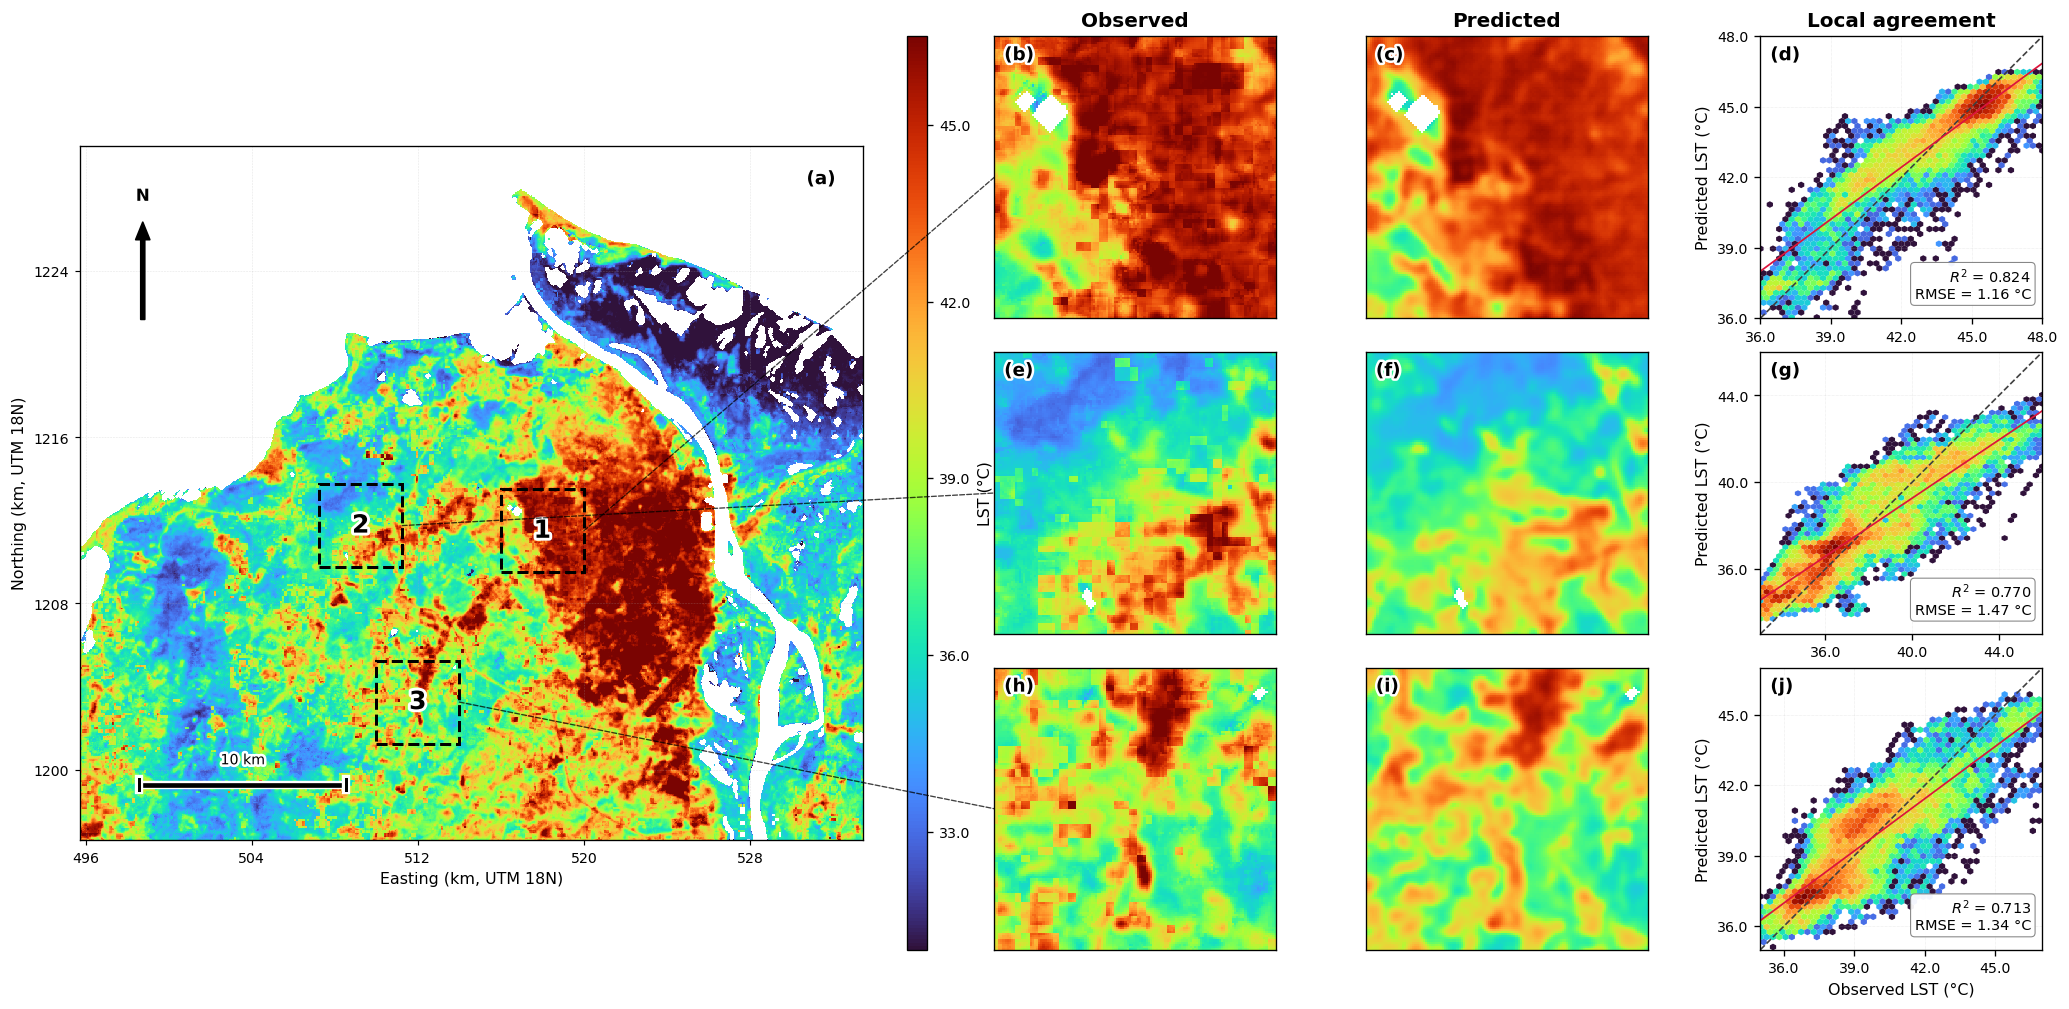

Zoom-in manuscript figure exported:
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09Z_M5_Q1_zoom_windows_observed_predicted_agreement_clean_2023.png
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09Z_M5_Q1_zoom_windows_observed_predicted_agreement_clean_2023.pdf
Metrics table:
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09Z_M5_Q1_zoom_window_metrics_clean_2023.csv
Metadata:
  /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09Z_M5_Q1_zoom_window_metadata_clean_2023.json


In [ ]:
# ============================================================
# 09Z — Manuscript zoom-in validation figure, clean Q1 version
# Project: Barranquilla LST/SUHI
# Model: M5 / T3-Climate ConvLSTM-SE U-Net
#
# Figure layout:
# (a) Full-domain observed LST with selected zoom windows
#
# For each selected window:
#     Observed zoom | Predicted zoom | Local pixel-wise agreement
#
# Final selected windows:
# Z1: Urban hotspot
# Z2: Vegetated–urban cooling transition
# Z3: Urban–periurban thermal transition
#
# Editorial decisions:
# - Only panel labels remain inside the figure.
# - Z1/Z2/Z3 descriptions are removed from zoom panels.
# - CRS/context information is removed from the figure footer.
# - Metrics boxes in agreement panels are moved to lower-right corner.
# - Local agreement legends are removed; explain 1:1 and fit lines in caption.
# - Observed and predicted maps use the same global LST color scale.
# ============================================================

from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from rasterio.windows import from_bounds
from rasterio.transform import array_bounds
from matplotlib.patches import Rectangle, ConnectionPatch
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter, FormatStrFormatter, MaxNLocator
import matplotlib.patheffects as pe


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MANUSCRIPT_YEAR = 2023

MAP_CMAP = "turbo"
DENSITY_CMAP = "turbo"

EXPORT_DPI = 600

try:
    MANUSCRIPT_FIG_DIR = FIG_DIR / "manuscript_q1"
except NameError:
    OUTPUT_DIR = Path(
        "/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/"
        "07_models/t3_climate/module08_independent_2016_2025/"
        "09_physical_unit_evaluation_and_exports"
    )
    FIG_DIR = OUTPUT_DIR / "figures"
    RASTER_DIR = OUTPUT_DIR / "rasters_celsius"
    TABLE_DIR = OUTPUT_DIR / "tables"
    MANUSCRIPT_FIG_DIR = FIG_DIR / "manuscript_q1"

MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)

OBS_TIF = RASTER_DIR / f"M5_observed_LST_C_{MANUSCRIPT_YEAR}.tif"
PRED_TIF = RASTER_DIR / f"M5_predicted_LST_C_{MANUSCRIPT_YEAR}.tif"

OUT_PNG = MANUSCRIPT_FIG_DIR / (
    f"09Z_M5_Q1_zoom_windows_observed_predicted_agreement_clean_{MANUSCRIPT_YEAR}.png"
)

OUT_PDF = MANUSCRIPT_FIG_DIR / (
    f"09Z_M5_Q1_zoom_windows_observed_predicted_agreement_clean_{MANUSCRIPT_YEAR}.pdf"
)

OUT_CSV = MANUSCRIPT_FIG_DIR / (
    f"09Z_M5_Q1_zoom_window_metrics_clean_{MANUSCRIPT_YEAR}.csv"
)

OUT_META = MANUSCRIPT_FIG_DIR / (
    f"09Z_M5_Q1_zoom_window_metadata_clean_{MANUSCRIPT_YEAR}.json"
)


# ------------------------------------------------------------
# Final selected zoom windows
# EPSG:32618 / WGS 84 UTM zone 18N
# ------------------------------------------------------------

ZOOM_WINDOWS = [
    {
        "zone": 1,
        "name": "Urban hotspot",
        "xmin": 516000.0,
        "xmax": 520000.0,
        "ymin": 1209500.0,
        "ymax": 1213500.0,
    },
    {
        "zone": 2,
        "name": "Vegetated–urban cooling transition",
        "xmin": 507250.0,
        "xmax": 511250.0,
        "ymin": 1209750.0,
        "ymax": 1213750.0,
    },
    {
        "zone": 3,
        "name": "Urban–periurban thermal transition",
        "xmin": 510000.0,
        "xmax": 514000.0,
        "ymin": 1201250.0,
        "ymax": 1205250.0,
    },
]


# ------------------------------------------------------------
# Style
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.0,
    "figure.dpi": 120,
    "savefig.dpi": EXPORT_DPI,
})


# ------------------------------------------------------------
# Raster utilities
# ------------------------------------------------------------

def read_single_band_raster_local(path):
    """Read a single-band raster and convert nodata to NaN."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Raster not found: {path}")

    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)

    return arr, profile, transform, crs


def raster_extent_from_profile_local(profile):
    """Return Matplotlib extent [west, east, south, north]."""
    west, south, east, north = array_bounds(
        profile["height"],
        profile["width"],
        profile["transform"]
    )

    return [west, east, south, north]


def window_slices_from_bounds(bounds, profile):
    """Convert map bounds to array slices."""
    xmin, ymin, xmax, ymax = bounds

    win = from_bounds(
        xmin,
        ymin,
        xmax,
        ymax,
        transform=profile["transform"]
    )

    row0 = int(np.floor(win.row_off))
    col0 = int(np.floor(win.col_off))
    row1 = int(np.ceil(win.row_off + win.height))
    col1 = int(np.ceil(win.col_off + win.width))

    row0 = max(row0, 0)
    col0 = max(col0, 0)
    row1 = min(row1, profile["height"])
    col1 = min(col1, profile["width"])

    if row1 <= row0 or col1 <= col0:
        return None

    return slice(row0, row1), slice(col0, col1)


def crop_by_bounds(arr, profile, xmin, ymin, xmax, ymax):
    """Crop a raster array using projected bounds."""
    slices = window_slices_from_bounds((xmin, ymin, xmax, ymax), profile)

    if slices is None:
        raise ValueError(f"Invalid crop bounds: {xmin}, {ymin}, {xmax}, {ymax}")

    rs, cs = slices
    return arr[rs, cs]


# ------------------------------------------------------------
# Metric and range utilities
# ------------------------------------------------------------

def compute_local_metrics(obs_win, pred_win):
    """Compute local pixel-wise metrics in °C."""
    valid = np.isfinite(obs_win) & np.isfinite(pred_win)

    y = obs_win[valid].astype("float64")
    p = pred_win[valid].astype("float64")

    if len(y) < 30:
        return {
            "n": int(len(y)),
            "r2": np.nan,
            "rmse_c": np.nan,
            "mae_c": np.nan,
            "bias_c": np.nan,
            "slope": np.nan,
            "intercept": np.nan,
        }

    err = p - y

    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    bias = float(np.mean(err))

    ss_res = float(np.sum((y - p) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    slope, intercept = np.polyfit(y, p, 1)

    return {
        "n": int(len(y)),
        "r2": float(r2),
        "rmse_c": rmse,
        "mae_c": mae,
        "bias_c": bias,
        "slope": float(slope),
        "intercept": float(intercept),
    }


def rounded_global_lST_range(obs_c, pred_c, valid, p_low=2, p_high=98):
    """
    Common global LST display range for observed and predicted maps.
    Rounded to 0.5 °C.
    """
    vals = np.concatenate([
        obs_c[valid & np.isfinite(obs_c)].ravel(),
        pred_c[valid & np.isfinite(pred_c)].ravel()
    ])

    vmin = float(np.percentile(vals, p_low))
    vmax = float(np.percentile(vals, p_high))

    vmin = math.floor(vmin * 2.0) / 2.0
    vmax = math.ceil(vmax * 2.0) / 2.0

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin = float(np.nanmin(vals))
        vmax = float(np.nanmax(vals))

    return vmin, vmax


def local_limited_range(values, p_low=0.5, p_high=99.5):
    """Display range for local agreement panels."""
    vals = values[np.isfinite(values)]

    if len(vals) == 0:
        return np.nan, np.nan

    vmin = float(np.percentile(vals, p_low))
    vmax = float(np.percentile(vals, p_high))

    vmin = math.floor(vmin * 2.0) / 2.0
    vmax = math.ceil(vmax * 2.0) / 2.0

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin = float(np.nanmin(vals))
        vmax = float(np.nanmax(vals))

    return vmin, vmax


# ------------------------------------------------------------
# Cartographic and plotting helpers
# ------------------------------------------------------------

def km_formatter(x, pos):
    """Format UTM coordinates in kilometres."""
    return f"{x / 1000:.0f}"


def style_overview_axis(ax, extent):
    """Style overview map axis."""
    west, east, south, north = extent

    ax.set_xlim(west, east)
    ax.set_ylim(south, north)
    ax.set_aspect("equal", adjustable="box")

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.xaxis.set_major_formatter(FuncFormatter(km_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(km_formatter))

    ax.set_xlabel("Easting (km, UTM 18N)")
    ax.set_ylabel("Northing (km, UTM 18N)")

    ax.grid(True, linestyle=":", linewidth=0.35, alpha=0.55)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=3,
        width=0.7
    )


def style_zoom_map_axis(ax):
    """Style zoom map panels."""
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("black")


def add_panel_label(ax, label, x=0.035, y=0.965, ha="left", va="top"):
    """Add panel label inside an axis."""
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha=ha,
        va=va,
        fontsize=11,
        fontweight="bold",
        color="black",
        path_effects=[
            pe.Stroke(linewidth=3.0, foreground="white"),
            pe.Normal()
        ],
        zorder=50
    )


def add_box_label(ax, x, y, label, fontsize=15):
    """Add numbered zoom-window label with white halo."""
    ax.text(
        x,
        y,
        str(label),
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
        color="black",
        path_effects=[
            pe.Stroke(linewidth=3.5, foreground="white"),
            pe.Normal()
        ],
        zorder=40
    )


def add_scale_bar_local(ax, extent, length_m=10000, location=(0.075, 0.08)):
    """Add a metric scale bar to the overview map."""
    west, east, south, north = extent
    width_m = east - west
    height_m = north - south

    x0 = west + location[0] * width_m
    y0 = south + location[1] * height_m
    x1 = x0 + length_m

    line_effect = [
        pe.Stroke(linewidth=5.0, foreground="white"),
        pe.Normal()
    ]

    ax.plot(
        [x0, x1],
        [y0, y0],
        color="black",
        linewidth=2.8,
        solid_capstyle="butt",
        path_effects=line_effect,
        zorder=45
    )

    ax.plot(
        [x0, x0],
        [y0 - 0.008 * height_m, y0 + 0.008 * height_m],
        color="black",
        linewidth=1.8,
        path_effects=line_effect,
        zorder=45
    )

    ax.plot(
        [x1, x1],
        [y0 - 0.008 * height_m, y0 + 0.008 * height_m],
        color="black",
        linewidth=1.8,
        path_effects=line_effect,
        zorder=45
    )

    label = f"{int(length_m / 1000)} km"

    ax.text(
        x0 + length_m / 2.0,
        y0 + 0.025 * height_m,
        label,
        ha="center",
        va="bottom",
        fontsize=8.5,
        color="black",
        path_effects=[
            pe.Stroke(linewidth=3.2, foreground="white"),
            pe.Normal()
        ],
        zorder=46
    )


def add_north_arrow_local(ax, location=(0.08, 0.89)):
    """Add north arrow to overview map."""
    x, y = location

    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - 0.14),
        xycoords="axes fraction",
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=2.4,
            headwidth=8.5,
            headlength=10.5
        ),
        zorder=45
    )

    ax.text(
        x,
        y + 0.025,
        "N",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
        path_effects=[
            pe.Stroke(linewidth=3.0, foreground="white"),
            pe.Normal()
        ],
        zorder=46
    )


# ------------------------------------------------------------
# Load rasters
# ------------------------------------------------------------

obs_c, obs_profile, obs_transform, obs_crs = read_single_band_raster_local(OBS_TIF)
pred_c, pred_profile, pred_transform, pred_crs = read_single_band_raster_local(PRED_TIF)

if obs_c.shape != pred_c.shape:
    raise ValueError(
        f"Observed and predicted rasters have different shapes: "
        f"{obs_c.shape} vs {pred_c.shape}"
    )

valid = np.isfinite(obs_c) & np.isfinite(pred_c)
extent = raster_extent_from_profile_local(obs_profile)

vmin, vmax = rounded_global_lST_range(
    obs_c,
    pred_c,
    valid,
    p_low=2,
    p_high=98
)

obs_plot = np.where(np.isfinite(obs_c), obs_c, np.nan)
pred_plot = np.where(np.isfinite(pred_c), pred_c, np.nan)

map_cmap = plt.get_cmap(MAP_CMAP).copy()
map_cmap.set_bad("white")

density_cmap = plt.get_cmap(DENSITY_CMAP).copy()
density_cmap.set_bad("white")

print("Zoom validation figure")
print("Observed raster :", OBS_TIF)
print("Predicted raster:", PRED_TIF)
print("CRS             :", obs_crs)
print("LST range       :", vmin, vmax)


# ------------------------------------------------------------
# Prepare zoom-window data
# ------------------------------------------------------------

zone_records = []

for z in ZOOM_WINDOWS:
    xmin = z["xmin"]
    xmax = z["xmax"]
    ymin = z["ymin"]
    ymax = z["ymax"]

    obs_win = crop_by_bounds(obs_c, obs_profile, xmin, ymin, xmax, ymax)
    pred_win = crop_by_bounds(pred_c, pred_profile, xmin, ymin, xmax, ymax)

    valid_win = np.isfinite(obs_win) & np.isfinite(pred_win)

    metrics_z = compute_local_metrics(obs_win, pred_win)

    combined_vals = np.concatenate([
        obs_win[valid_win].ravel(),
        pred_win[valid_win].ravel()
    ])

    xy_min, xy_max = local_limited_range(
        combined_vals,
        p_low=0.5,
        p_high=99.5
    )

    zone_record = {
        **z,
        "obs_win": obs_win,
        "pred_win": pred_win,
        "valid_win": valid_win,
        "extent": [xmin, xmax, ymin, ymax],
        "xy_min": xy_min,
        "xy_max": xy_max,
        **metrics_z,
    }

    zone_records.append(zone_record)


metrics_table = pd.DataFrame([
    {
        "zone": z["zone"],
        "name": z["name"],
        "xmin": z["xmin"],
        "xmax": z["xmax"],
        "ymin": z["ymin"],
        "ymax": z["ymax"],
        "n": z["n"],
        "r2": z["r2"],
        "rmse_c": z["rmse_c"],
        "mae_c": z["mae_c"],
        "bias_c": z["bias_c"],
        "slope": z["slope"],
        "intercept": z["intercept"],
    }
    for z in zone_records
])

metrics_table.to_csv(OUT_CSV, index=False)

print("Zoom-window metrics:")
display(metrics_table[[
    "zone",
    "name",
    "r2",
    "rmse_c",
    "mae_c",
    "bias_c",
    "slope",
    "intercept",
    "n"
]])


# ------------------------------------------------------------
# Build manuscript figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(17.8, 8.6), constrained_layout=False)

# Layout:
# Left: full observed map + colorbar
# Right: 3 rows × 3 columns:
#        Observed zoom | Predicted zoom | Local agreement
gs = fig.add_gridspec(
    nrows=3,
    ncols=5,
    width_ratios=[1.72, 0.045, 0.72, 0.72, 0.82],
    height_ratios=[1.0, 1.0, 1.0],
    left=0.045,
    right=0.985,
    bottom=0.055,
    top=0.94,
    wspace=0.12,
    hspace=0.12
)

ax_main = fig.add_subplot(gs[:, 0])
cax_lst = fig.add_subplot(gs[:, 1])

axes_obs_zoom = []
axes_pred_zoom = []
axes_agree = []

for i in range(3):
    axes_obs_zoom.append(fig.add_subplot(gs[i, 2]))
    axes_pred_zoom.append(fig.add_subplot(gs[i, 3]))
    axes_agree.append(fig.add_subplot(gs[i, 4]))


# ------------------------------------------------------------
# Panel (a): overview map
# ------------------------------------------------------------

im_main = ax_main.imshow(
    obs_plot,
    cmap=map_cmap,
    vmin=vmin,
    vmax=vmax,
    extent=extent,
    origin="upper",
    interpolation="nearest"
)

style_overview_axis(ax_main, extent)

# No long title in the figure.
# Caption should describe: "Observed LST with selected zoom-in windows".
ax_main.set_title("")

# Panel label inside upper-right corner
add_panel_label(
    ax_main,
    "(a)",
    x=0.965,
    y=0.965,
    ha="right",
    va="top"
)

# Scale and north arrow
add_scale_bar_local(
    ax_main,
    extent,
    length_m=10000,
    location=(0.075, 0.08)
)

add_north_arrow_local(
    ax_main,
    location=(0.08, 0.89)
)

# Draw zoom boxes
for z in zone_records:
    width = z["xmax"] - z["xmin"]
    height = z["ymax"] - z["ymin"]

    rect = Rectangle(
        (z["xmin"], z["ymin"]),
        width,
        height,
        fill=False,
        edgecolor="black",
        linewidth=1.8,
        linestyle="--",
        zorder=35
    )

    ax_main.add_patch(rect)

    add_box_label(
        ax_main,
        z["xmin"] + width / 2.0,
        z["ymin"] + height / 2.0,
        z["zone"],
        fontsize=15
    )


# LST colorbar
cb_lst = fig.colorbar(
    im_main,
    cax=cax_lst,
    orientation="vertical"
)

cb_lst.set_label("LST (°C)")
cb_lst.ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
cb_lst.ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
cb_lst.ax.tick_params(labelsize=8.5)


# ------------------------------------------------------------
# Column headers
# ------------------------------------------------------------

axes_obs_zoom[0].set_title("Observed", fontsize=12, fontweight="bold")
axes_pred_zoom[0].set_title("Predicted", fontsize=12, fontweight="bold")
axes_agree[0].set_title("Local agreement", fontsize=12, fontweight="bold")


# ------------------------------------------------------------
# Zoom panels and local agreement panels
# ------------------------------------------------------------

panel_labels = [
    ("(b)", "(c)", "(d)"),
    ("(e)", "(f)", "(g)"),
    ("(h)", "(i)", "(j)"),
]

for i, z in enumerate(zone_records):

    obs_win = np.where(z["valid_win"], z["obs_win"], np.nan)
    pred_win = np.where(z["valid_win"], z["pred_win"], np.nan)

    extent_z = z["extent"]

    # --------------------------------------------------------
    # Observed zoom
    # --------------------------------------------------------
    ax_o = axes_obs_zoom[i]

    ax_o.imshow(
        obs_win,
        cmap=map_cmap,
        vmin=vmin,
        vmax=vmax,
        extent=extent_z,
        origin="upper",
        interpolation="nearest"
    )

    style_zoom_map_axis(ax_o)
    add_panel_label(ax_o, panel_labels[i][0])

    # No Z1/Z2/Z3 semantic text inside zoom panel.
    # Descriptions go in the figure caption.

    # --------------------------------------------------------
    # Predicted zoom
    # --------------------------------------------------------
    ax_p = axes_pred_zoom[i]

    ax_p.imshow(
        pred_win,
        cmap=map_cmap,
        vmin=vmin,
        vmax=vmax,
        extent=extent_z,
        origin="upper",
        interpolation="nearest"
    )

    style_zoom_map_axis(ax_p)
    add_panel_label(ax_p, panel_labels[i][1])

    # --------------------------------------------------------
    # Local agreement
    # --------------------------------------------------------
    ax_a = axes_agree[i]

    y = z["obs_win"][z["valid_win"]].astype("float64")
    p = z["pred_win"][z["valid_win"]].astype("float64")

    xy_min = z["xy_min"]
    xy_max = z["xy_max"]

    display_mask = (
        np.isfinite(y) &
        np.isfinite(p) &
        (y >= xy_min) & (y <= xy_max) &
        (p >= xy_min) & (p <= xy_max)
    )

    y_plot = y[display_mask]
    p_plot = p[display_mask]

    hb = ax_a.hexbin(
        y_plot,
        p_plot,
        gridsize=45,
        mincnt=1,
        cmap=density_cmap,
        norm=LogNorm(),
        linewidths=0.0
    )

    # 1:1 reference line
    ax_a.plot(
        [xy_min, xy_max],
        [xy_min, xy_max],
        linestyle="--",
        linewidth=1.0,
        color="0.25"
    )

    # Fitted regression line
    xfit = np.linspace(xy_min, xy_max, 100)
    yfit = z["slope"] * xfit + z["intercept"]

    ax_a.plot(
        xfit,
        yfit,
        linestyle="-",
        linewidth=1.05,
        color="crimson"
    )

    ax_a.set_xlim(xy_min, xy_max)
    ax_a.set_ylim(xy_min, xy_max)
    ax_a.set_aspect("equal", adjustable="box")

    ax_a.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax_a.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax_a.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax_a.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    ax_a.grid(
        True,
        linestyle=":",
        linewidth=0.30,
        alpha=0.55
    )

    if i == 2:
        ax_a.set_xlabel("Observed LST (°C)")
    else:
        ax_a.set_xlabel("")

    ax_a.set_ylabel("Predicted LST (°C)")

    add_panel_label(ax_a, panel_labels[i][2])

    metrics_txt = (
        f"$R^2$ = {z['r2']:.3f}\n"
        f"RMSE = {z['rmse_c']:.2f} °C"
    )

    # Metrics moved to lower-right corner to avoid overlap with panel label.
    ax_a.text(
        0.96,
        0.06,
        metrics_txt,
        transform=ax_a.transAxes,
        ha="right",
        va="bottom",
        fontsize=8.7,
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="0.50",
            linewidth=0.65,
            alpha=0.94
        ),
        zorder=55
    )

    # No legend inside local panels.
    # The 1:1 and fitted regression lines should be described in the caption.


# ------------------------------------------------------------
# Dashed connectors from overview boxes to observed zoom panels
# ------------------------------------------------------------

for i, z in enumerate(zone_records):
    con = ConnectionPatch(
        xyA=(z["xmax"], (z["ymin"] + z["ymax"]) / 2.0),
        coordsA=ax_main.transData,
        xyB=(0.0, 0.5),
        coordsB=axes_obs_zoom[i].transAxes,
        linestyle="--",
        linewidth=0.8,
        color="black",
        alpha=0.75,
        zorder=10
    )

    fig.add_artist(con)


# ------------------------------------------------------------
# Export figure
# ------------------------------------------------------------

fig.savefig(
    OUT_PNG,
    dpi=EXPORT_DPI,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUT_PDF,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# Export metadata
# ------------------------------------------------------------

metadata = {
    "figure": "09Z_M5_Q1_zoom_windows_observed_predicted_agreement_clean",
    "year": int(MANUSCRIPT_YEAR),
    "model": "M5 / T3-Climate ConvLSTM-SE U-Net",
    "split": "test",
    "observed_raster": str(OBS_TIF),
    "predicted_raster": str(PRED_TIF),
    "output_png": str(OUT_PNG),
    "output_pdf": str(OUT_PDF),
    "metrics_csv": str(OUT_CSV),
    "crs": str(obs_crs),
    "lst_display_range_c": {
        "vmin": float(vmin),
        "vmax": float(vmax),
        "percentiles": "p02-p98 rounded to 0.5 °C"
    },
    "zoom_windows": [
        {
            "zone": int(z["zone"]),
            "name": z["name"],
            "xmin": float(z["xmin"]),
            "xmax": float(z["xmax"]),
            "ymin": float(z["ymin"]),
            "ymax": float(z["ymax"]),
            "r2": float(z["r2"]),
            "rmse_c": float(z["rmse_c"]),
            "mae_c": float(z["mae_c"]),
            "bias_c": float(z["bias_c"]),
            "n": int(z["n"]),
            "slope": float(z["slope"]),
            "intercept": float(z["intercept"]),
        }
        for z in zone_records
    ],
    "styling": {
        "lst_cmap": MAP_CMAP,
        "density_cmap": DENSITY_CMAP,
        "export_dpi": EXPORT_DPI,
        "observed_predicted_same_color_scale": True,
        "infigure_footer_removed": True,
        "zone_context_descriptions_in_caption": True
    }
}

with open(OUT_META, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Zoom-in manuscript figure exported:")
print(" ", OUT_PNG)
print(" ", OUT_PDF)
print("Metrics table:")
print(" ", OUT_CSV)
print("Metadata:")
print(" ", OUT_META)


---

## 09Y — Annual multimetric TEST evaluation figure

This supplementary module creates the revised manuscript Figure 4 without modifying any previous calculation, table, figure, raster export, or manuscript module in this notebook.

The figure jointly represents the annual TEST behavior of the five configurations during 2023–2025 using:

- **(a) RMSE (°C)**
- **(b) MAE (°C)**
- **(c) R²**
- **(d) Bias (°C)**

The module uses the already validated `year_c` table generated above. If the notebook is resumed from this point in a new session, it can reload the exported annual Celsius table from disk. No metric is recalculated from predictions in this module.


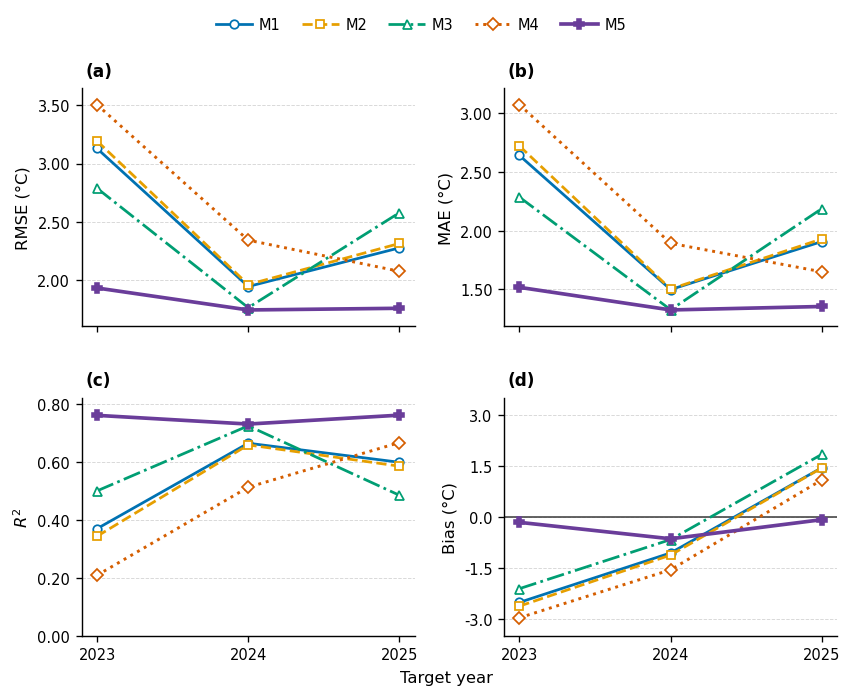

09Y completed successfully.
Source: In-memory `year_c` table generated by Notebook 09.
Plotted rows: 15
Figure PNG: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09Y_Figure4_TEST_annual_multimetric_2023_2025_final.png
Figure PDF: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09Y_Figure4_TEST_annual_multimetric_2023_2025_final.pdf
Figure SVG: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/figures/manuscript_q1/09Y_Figure4_TEST_annual_multimetric_2023_2025_final.svg
Data CSV: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/07_models/t3_climate/module08_independent_2016_2025/09_physical_unit_evaluation_and_exports/tables/09Y_F

,model_short,target_year,rmse_c,mae_c,r2,bias_c
0,M1,2023,3.129422,2.638970,0.369157,-2.515540
1,M1,2024,1.944957,1.498102,0.663583,-1.060580
2,M1,2025,2.276496,1.906744,0.597910,1.444475
3,M2,2023,3.193503,2.719619,0.343057,-2.625571
4,M2,2024,1.961795,1.503178,0.657733,-1.124272
5,M2,2025,2.314333,1.928925,0.584433,1.437936
6,M3,2023,2.788093,2.284308,0.499265,-2.111807
7,M3,2024,1.763539,1.326538,0.723415,-0.668302
8,M3,2025,2.578213,2.186775,0.484264,1.837343
9,M4,2023,3.504795,3.070840,0.208742,-2.968290


In [ ]:
# ============================================================
# 09Y — Annual multimetric TEST evaluation figure
# Revised manuscript Figure 4 — final Q1 version
#
# IMPORTANT
# - This module is appended at the end of Notebook 09.
# - It does not modify or replace any previous calculation.
# - It uses the annual Celsius metrics already produced in `year_c`.
# - It does not recalculate metrics from pixel predictions.
#
# Panels:
# (a) RMSE (°C)
# (b) MAE (°C)
# (c) R²
# (d) Bias (°C)
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FormatStrFormatter


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

FIGURE4_TEST_YEARS = [2023, 2024, 2025]
FIGURE4_EXPORT_DPI = 600

# Independent output folder for the revised manuscript figure.
FIGURE4_DIR = FIG_DIR / "manuscript_q1"
FIGURE4_DIR.mkdir(parents=True, exist_ok=True)

FIGURE4_PNG = (
    FIGURE4_DIR
    / "09Y_Figure4_TEST_annual_multimetric_2023_2025_final.png"
)

FIGURE4_PDF = (
    FIGURE4_DIR
    / "09Y_Figure4_TEST_annual_multimetric_2023_2025_final.pdf"
)

FIGURE4_SVG = (
    FIGURE4_DIR
    / "09Y_Figure4_TEST_annual_multimetric_2023_2025_final.svg"
)

FIGURE4_CSV = (
    TABLE_DIR
    / "09Y_Figure4_TEST_annual_multimetric_2023_2025_final.csv"
)

FIGURE4_META = (
    METADATA_DIR
    / "09Y_Figure4_TEST_annual_multimetric_2023_2025_final_metadata.json"
)

# Previously exported annual physical-unit metrics.
FIGURE4_SOURCE_CSV = (
    TABLE_DIR
    / "09_model_comparison_by_year_celsius.csv"
)


# ------------------------------------------------------------
# 2. Model definitions
# ------------------------------------------------------------

MODEL_ORDER_09Y = [
    "M1_UNet",
    "M2_SE_UNet",
    "M3_ConvLSTM_UNet",
    "M4_ConvLSTM_SE_UNet",
    "M5_T3Climate_ConvLSTM_SE_UNet",
]

MODEL_SHORT_LABELS_09Y = {
    "M1_UNet": "M1",
    "M2_SE_UNet": "M2",
    "M3_ConvLSTM_UNet": "M3",
    "M4_ConvLSTM_SE_UNet": "M4",
    "M5_T3Climate_ConvLSTM_SE_UNet": "M5",
}

MODEL_FULL_LABELS_09Y = {
    "M1_UNet": "M1 — U-Net 2D",
    "M2_SE_UNet": "M2 — SE U-Net",
    "M3_ConvLSTM_UNet": "M3 — ConvLSTM U-Net",
    "M4_ConvLSTM_SE_UNet": "M4 — ConvLSTM-SE U-Net",
    "M5_T3Climate_ConvLSTM_SE_UNet":
        "M5 — T3-Climate ConvLSTM-SE U-Net",
}


# ------------------------------------------------------------
# 3. Final visual encoding
#
# Changes relative to the previous version:
# - M4 changed from orange to red.
# - M5 remains highlighted, but less aggressively.
# - Marker and line differences are retained for grayscale output.
# ------------------------------------------------------------

MODEL_STYLES_09Y = {
    "M1_UNet": {
        "color": "#0072B2",
        "marker": "o",
        "linestyle": "-",
        "linewidth": 1.65,
        "markersize": 5.1,
        "markerfacecolor": "white",
        "markeredgewidth": 1.05,
        "zorder": 3,
    },

    "M2_SE_UNet": {
        "color": "#E69F00",
        "marker": "s",
        "linestyle": "--",
        "linewidth": 1.65,
        "markersize": 5.0,
        "markerfacecolor": "white",
        "markeredgewidth": 1.05,
        "zorder": 3,
    },

    "M3_ConvLSTM_UNet": {
        "color": "#009E73",
        "marker": "^",
        "linestyle": "-.",
        "linewidth": 1.65,
        "markersize": 5.4,
        "markerfacecolor": "white",
        "markeredgewidth": 1.05,
        "zorder": 3,
    },

    "M4_ConvLSTM_SE_UNet": {
        "color": "#D55E00",
        "marker": "D",
        "linestyle": ":",
        "linewidth": 1.75,
        "markersize": 5.0,
        "markerfacecolor": "white",
        "markeredgewidth": 1.05,
        "zorder": 3,
    },

    "M5_T3Climate_ConvLSTM_SE_UNet": {
        "color": "#6A3D9A",
        "marker": "P",
        "linestyle": "-",
        "linewidth": 2.20,
        "markersize": 5.9,
        "markerfacecolor": "#6A3D9A",
        "markeredgewidth": 0.95,
        "zorder": 5,
    },
}


# ------------------------------------------------------------
# 4. Load annual TEST metrics
# ------------------------------------------------------------

if "year_c" in globals() and isinstance(year_c, pd.DataFrame):
    figure4_source = year_c.copy()
    figure4_source_origin = (
        "In-memory `year_c` table generated by Notebook 09."
    )

elif FIGURE4_SOURCE_CSV.exists():
    figure4_source = pd.read_csv(FIGURE4_SOURCE_CSV)
    figure4_source_origin = str(FIGURE4_SOURCE_CSV)

else:
    raise FileNotFoundError(
        "The annual Celsius metrics are unavailable.\n\n"
        "Either:\n"
        "1. run the preceding cells that generate `year_c`, or\n"
        "2. verify that the following file exists:\n"
        f"   {FIGURE4_SOURCE_CSV}"
    )


# ------------------------------------------------------------
# 5. Validate input table
# ------------------------------------------------------------

required_cols_09y = {
    "model",
    "split",
    "target_year",
    "rmse_c",
    "mae_c",
    "bias_c",
    "r2",
}

missing_cols_09y = sorted(
    required_cols_09y.difference(figure4_source.columns)
)

if missing_cols_09y:
    raise ValueError(
        "The annual metrics table does not contain the required "
        "columns:\n  "
        + ", ".join(missing_cols_09y)
    )

figure4_df = figure4_source.copy()

figure4_df["target_year"] = pd.to_numeric(
    figure4_df["target_year"],
    errors="coerce",
)

figure4_df = figure4_df.loc[
    figure4_df["split"].astype(str).str.lower().eq("test")
    & figure4_df["target_year"].isin(FIGURE4_TEST_YEARS)
    & figure4_df["model"].isin(MODEL_ORDER_09Y)
].copy()

figure4_df["target_year"] = (
    figure4_df["target_year"].astype(int)
)


# ------------------------------------------------------------
# 6. Validate model-year combinations
# ------------------------------------------------------------

duplicate_counts_09y = (
    figure4_df
    .groupby(["model", "target_year"], dropna=False)
    .size()
    .reset_index(name="n")
)

duplicates_09y = duplicate_counts_09y.loc[
    duplicate_counts_09y["n"] != 1
]

if not duplicates_09y.empty:
    raise ValueError(
        "Each model-year combination must occur exactly once.\n"
        "Problematic combinations:\n"
        + duplicates_09y.to_string(index=False)
    )

expected_pairs_09y = pd.MultiIndex.from_product(
    [
        MODEL_ORDER_09Y,
        FIGURE4_TEST_YEARS,
    ],
    names=[
        "model",
        "target_year",
    ],
)

observed_pairs_09y = pd.MultiIndex.from_frame(
    figure4_df[
        [
            "model",
            "target_year",
        ]
    ]
)

missing_pairs_09y = expected_pairs_09y.difference(
    observed_pairs_09y
)

if len(missing_pairs_09y):
    missing_text_09y = ", ".join(
        f"{model}, {year}"
        for model, year in missing_pairs_09y
    )

    raise ValueError(
        "The figure cannot be generated because annual TEST "
        "metrics are missing for:\n"
        f"  {missing_text_09y}"
    )


# ------------------------------------------------------------
# 7. Validate metric values
# ------------------------------------------------------------

metric_cols_09y = [
    "rmse_c",
    "mae_c",
    "r2",
    "bias_c",
]

metric_array_09y = figure4_df[
    metric_cols_09y
].to_numpy(dtype=float)

nonfinite_09y = ~np.isfinite(metric_array_09y)

if nonfinite_09y.any():
    bad_rows_09y = figure4_df.loc[
        nonfinite_09y.any(axis=1),
        [
            "model",
            "target_year",
            "rmse_c",
            "mae_c",
            "r2",
            "bias_c",
        ],
    ]

    raise ValueError(
        "Non-finite values were found in the metrics used by "
        "Figure 4:\n"
        + bad_rows_09y.to_string(index=False)
    )


# ------------------------------------------------------------
# 8. Prepare auditable export table
# ------------------------------------------------------------

figure4_df["model_short"] = (
    figure4_df["model"]
    .map(MODEL_SHORT_LABELS_09Y)
)

figure4_df["model_full"] = (
    figure4_df["model"]
    .map(MODEL_FULL_LABELS_09Y)
)

figure4_df["model_order"] = (
    figure4_df["model"]
    .map(
        {
            model: index + 1
            for index, model in enumerate(MODEL_ORDER_09Y)
        }
    )
)

figure4_df = (
    figure4_df
    .sort_values(
        [
            "model_order",
            "target_year",
        ]
    )
    .reset_index(drop=True)
)

figure4_export_cols = [
    "model_order",
    "model",
    "model_short",
    "model_full",
    "split",
    "target_year",
    "rmse_c",
    "mae_c",
    "r2",
    "bias_c",
]

for optional_col_09y in [
    "n_valid_pixels",
    "loss_c",
    "best_epoch",
]:
    if optional_col_09y in figure4_df.columns:
        figure4_export_cols.append(optional_col_09y)

figure4_df[
    figure4_export_cols
].to_csv(
    FIGURE4_CSV,
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------------------------
# 9. Axis utilities
# ------------------------------------------------------------

def padded_limits_09y(
    values,
    relative_pad=0.08,
    minimum_pad=0.05,
    lower_bound=None,
    upper_bound=None,
):
    """
    Calculate finite axis limits with controlled padding.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        raise ValueError(
            "Cannot calculate axis limits from an empty array."
        )

    value_min = float(np.min(values))
    value_max = float(np.max(values))
    value_span = value_max - value_min

    if value_span == 0:
        padding = max(
            abs(value_min) * relative_pad,
            minimum_pad,
        )
    else:
        padding = max(
            value_span * relative_pad,
            minimum_pad,
        )

    axis_min = value_min - padding
    axis_max = value_max + padding

    if lower_bound is not None:
        axis_min = max(lower_bound, axis_min)

    if upper_bound is not None:
        axis_max = min(upper_bound, axis_max)

    return axis_min, axis_max


def symmetric_bias_limits_09y(
    values,
    step=0.5,
    relative_pad=0.06,
):
    """
    Return symmetric bias limits centered on zero.

    Limits are rounded upward to the nearest specified step.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        raise ValueError(
            "Cannot calculate bias limits from an empty array."
        )

    maximum_absolute_value = float(
        np.max(np.abs(values))
    )

    padded_maximum = (
        maximum_absolute_value
        * (1.0 + relative_pad)
    )

    rounded_limit = (
        np.ceil(padded_maximum / step)
        * step
    )

    return -rounded_limit, rounded_limit


# ------------------------------------------------------------
# 10. Final figure style
# ------------------------------------------------------------

rc_09y = {
    "font.family": "DejaVu Sans",
    "font.size": 9.4,
    "axes.titlesize": 9.8,
    "axes.labelsize": 9.8,
    "xtick.labelsize": 8.8,
    "ytick.labelsize": 8.8,
    "legend.fontsize": 8.8,
    "axes.linewidth": 0.85,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "savefig.dpi": FIGURE4_EXPORT_DPI,
}

panel_specs_09y = [
    {
        "panel": "(a)",
        "metric": "rmse_c",
        "ylabel": "RMSE (°C)",
        "formatter": FormatStrFormatter("%.2f"),
    },
    {
        "panel": "(b)",
        "metric": "mae_c",
        "ylabel": "MAE (°C)",
        "formatter": FormatStrFormatter("%.2f"),
    },
    {
        "panel": "(c)",
        "metric": "r2",
        "ylabel": r"$R^2$",
        "formatter": FormatStrFormatter("%.2f"),
    },
    {
        "panel": "(d)",
        "metric": "bias_c",
        "ylabel": "Bias (°C)",
        "formatter": FormatStrFormatter("%.1f"),
    },
]


# ------------------------------------------------------------
# 11. Generate revised Figure 4
# ------------------------------------------------------------

with plt.rc_context(rc_09y):

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(7.15, 5.85),
        sharex=True,
        constrained_layout=False,
    )

    axes = axes.ravel()

    legend_handles_09y = []
    legend_labels_09y = []

    for ax, spec in zip(
        axes,
        panel_specs_09y,
    ):
        metric_name_09y = spec["metric"]

        for model_name_09y in MODEL_ORDER_09Y:

            model_df_09y = (
                figure4_df.loc[
                    figure4_df["model"]
                    == model_name_09y
                ]
                .sort_values("target_year")
            )

            style_09y = (
                MODEL_STYLES_09Y[
                    model_name_09y
                ]
            )

            line_09y, = ax.plot(
                model_df_09y[
                    "target_year"
                ].to_numpy(),

                model_df_09y[
                    metric_name_09y
                ].to_numpy(),

                label=MODEL_SHORT_LABELS_09Y[
                    model_name_09y
                ],

                color=style_09y["color"],
                marker=style_09y["marker"],
                linestyle=style_09y["linestyle"],
                linewidth=style_09y["linewidth"],
                markersize=style_09y["markersize"],
                markerfacecolor=(
                    style_09y["markerfacecolor"]
                ),
                markeredgecolor=style_09y["color"],
                markeredgewidth=(
                    style_09y["markeredgewidth"]
                ),
                zorder=style_09y["zorder"],
            )

            if ax is axes[0]:
                legend_handles_09y.append(
                    line_09y
                )
                legend_labels_09y.append(
                    MODEL_SHORT_LABELS_09Y[
                        model_name_09y
                    ]
                )

        # -----------------------------------------------
        # General panel formatting
        # -----------------------------------------------

        ax.set_ylabel(
            spec["ylabel"]
        )

        ax.set_xticks(
            FIGURE4_TEST_YEARS
        )

        ax.set_xticklabels(
            [
                str(year)
                for year in FIGURE4_TEST_YEARS
            ]
        )

        ax.yaxis.set_major_formatter(
            spec["formatter"]
        )

        # Horizontal grid only.
        ax.grid(
            True,
            axis="y",
            which="major",
            linestyle="--",
            linewidth=0.55,
            alpha=0.35,
            color="0.55",
        )

        ax.grid(
            False,
            axis="x",
        )

        ax.set_axisbelow(True)

        ax.spines["top"].set_visible(
            False
        )

        ax.spines["right"].set_visible(
            False
        )

        # Panel label placed above the plotting area to avoid
        # interference with the first data point.
        ax.text(
            0.01,
            1.035,
            spec["panel"],
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10.1,
            fontweight="bold",
            clip_on=False,
        )

        metric_values_09y = (
            figure4_df[
                metric_name_09y
            ]
            .to_numpy(dtype=float)
        )

         # -----------------------------------------------
        # Metric-specific axis treatment
        # -----------------------------------------------

        if metric_name_09y == "bias_c":

            # Zero-bias reference line.
            ax.axhline(
                y=0.0,
                color="0.25",
                linewidth=0.95,
                linestyle="-",
                zorder=1,
            )

            # Symmetric limits around zero.
            bias_lower_09y, bias_upper_09y = (
                symmetric_bias_limits_09y(
                    metric_values_09y,
                    step=0.5,
                    relative_pad=0.05,
                )
            )

            ax.set_ylim(
                bias_lower_09y,
                bias_upper_09y,
            )

            # Construct major ticks from zero toward both directions.
            # This guarantees that the horizontal reference line is
            # explicitly labelled as 0.0 on the y-axis.
            bias_tick_step_09y = 1.5

            negative_ticks_09y = np.arange(
                0.0,
                bias_lower_09y - 0.001,
                -bias_tick_step_09y,
            )

            positive_ticks_09y = np.arange(
                0.0,
                bias_upper_09y + 0.001,
                bias_tick_step_09y,
            )

            bias_ticks_09y = np.unique(
                np.concatenate(
                    [
                        negative_ticks_09y,
                        positive_ticks_09y,
                    ]
                )
            )

            bias_ticks_09y.sort()

            ax.yaxis.set_major_locator(
                FixedLocator(
                    bias_ticks_09y
                )
            )

            ax.yaxis.set_major_formatter(
                FormatStrFormatter("%.1f")
            )

        elif metric_name_09y == "r2":

            # Conservative presentation beginning at zero to avoid
            # visual exaggeration of differences among configurations.
            ax.set_ylim(
                0.0,
                0.82,
            )

            ax.yaxis.set_major_locator(
                FixedLocator(
                    [
                        0.0,
                        0.2,
                        0.4,
                        0.6,
                        0.8,
                    ]
                )
            )

            ax.yaxis.set_major_formatter(
                FormatStrFormatter("%.2f")
            )

        elif metric_name_09y == "rmse_c":

            rmse_lower_09y, rmse_upper_09y = (
                padded_limits_09y(
                    metric_values_09y,
                    relative_pad=0.08,
                    minimum_pad=0.08,
                    lower_bound=0.0,
                )
            )

            ax.set_ylim(
                rmse_lower_09y,
                rmse_upper_09y,
            )

            ax.yaxis.set_major_formatter(
                FormatStrFormatter("%.2f")
            )

        elif metric_name_09y == "mae_c":

            mae_lower_09y, mae_upper_09y = (
                padded_limits_09y(
                    metric_values_09y,
                    relative_pad=0.08,
                    minimum_pad=0.08,
                    lower_bound=0.0,
                )
            )

            ax.set_ylim(
                mae_lower_09y,
                mae_upper_09y,
            )

            ax.yaxis.set_major_formatter(
                FormatStrFormatter("%.2f")
            )

    # --------------------------------------------------------
    # 12. Shared x-axis label
    # --------------------------------------------------------

    fig.supxlabel(
        "Target year",
        x=0.53,
        y=0.035,
        fontsize=9.8,
    )


    # --------------------------------------------------------
    # 13. Shared legend
    # --------------------------------------------------------

    fig.legend(
        legend_handles_09y,
        legend_labels_09y,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.995),
        ncol=5,
        frameon=False,
        handlelength=2.5,
        columnspacing=1.45,
        handletextpad=0.45,
        borderaxespad=0.0,
    )


    # --------------------------------------------------------
    # 14. Compact editorial layout
    # --------------------------------------------------------

    fig.subplots_adjust(
        left=0.105,
        right=0.985,
        bottom=0.105,
        top=0.885,
        wspace=0.27,
        hspace=0.30,
    )


    # --------------------------------------------------------
    # 15. Export
    # --------------------------------------------------------

    fig.savefig(
        FIGURE4_PNG,
        dpi=FIGURE4_EXPORT_DPI,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
    )

    fig.savefig(
        FIGURE4_PDF,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
    )

    fig.savefig(
        FIGURE4_SVG,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="none",
    )

    plt.show()


# ------------------------------------------------------------
# 16. Metadata
# ------------------------------------------------------------

figure4_metadata_09y = {
    "module": (
        "09Y_annual_multimetric_TEST_evaluation_final"
    ),

    "purpose": (
        "Create the final manuscript Figure 4 showing annual "
        "TEST RMSE, MAE, R2 and bias for models M1-M5 during "
        "2023-2025."
    ),

    "source": figure4_source_origin,

    "source_table_not_recalculated": True,

    "split": "test",

    "years": FIGURE4_TEST_YEARS,

    "panels": {
        "a": "RMSE in degrees Celsius",
        "b": "MAE in degrees Celsius",
        "c": "coefficient of determination R2",
        "d": "mean bias in degrees Celsius",
    },

    "bias_definition": (
        "mean(predicted LST - observed LST)"
    ),

    "bias_interpretation": {
        "positive": "mean overestimation",
        "negative": "mean underestimation",
    },

    "r2_axis": {
        "minimum": 0.0,
        "maximum": 0.82,
        "reason": (
            "Conservative non-truncated presentation to avoid "
            "visual exaggeration of intermodel differences."
        ),
    },

    "models": [
        {
            "model": model_name_09y,
            "short_label": (
                MODEL_SHORT_LABELS_09Y[
                    model_name_09y
                ]
            ),
            "full_label": (
                MODEL_FULL_LABELS_09Y[
                    model_name_09y
                ]
            ),
        }
        for model_name_09y
        in MODEL_ORDER_09Y
    ],

    "outputs": {
        "png_600_dpi": str(FIGURE4_PNG),
        "pdf_vector": str(FIGURE4_PDF),
        "svg_vector": str(FIGURE4_SVG),
        "plotted_data_csv": str(FIGURE4_CSV),
    },

    "methodological_note": (
        "These metrics are aggregated by target year over TEST "
        "pixel-year observations. They are not full-domain raster "
        "metrics and must not be mixed with the assembled "
        "full-domain spatial evaluation."
    ),
}

with FIGURE4_META.open(
    "w",
    encoding="utf-8",
) as metadata_file_09y:

    json.dump(
        figure4_metadata_09y,
        metadata_file_09y,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------
# 17. Execution report
# ------------------------------------------------------------

print(
    "09Y completed successfully."
)

print(
    "Source:",
    figure4_source_origin,
)

print(
    "Plotted rows:",
    len(figure4_df),
)

print(
    "Figure PNG:",
    FIGURE4_PNG,
)

print(
    "Figure PDF:",
    FIGURE4_PDF,
)

print(
    "Figure SVG:",
    FIGURE4_SVG,
)

print(
    "Data CSV:",
    FIGURE4_CSV,
)

print(
    "Metadata:",
    FIGURE4_META,
)

print(
    "\nAnnual TEST metrics used in the figure:"
)

display_cols_09y = [
    "model_short",
    "target_year",
    "rmse_c",
    "mae_c",
    "r2",
    "bias_c",
]

try:
    display(
        figure4_df[
            display_cols_09y
        ]
    )

except NameError:
    print(
        figure4_df[
            display_cols_09y
        ].to_string(index=False)
    )